# C284045 최원오 머신러닝 기말 프로젝트 - CNN 

# 시작 전 설정

In [3]:
import os
import tensorflow as tf

# 1. 텐서플로우 C++ 엔진의 자잘한 경고 끄기 
# (0 = 모두 출력, 1 = INFO 끄기, 2 = WARNING 끄기, 3 = ERROR만 출력)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# 2. 파이썬 단에서 발생하는 텐서플로우 경고 끄기
tf.get_logger().setLevel('ERROR')

# 전처리

In [2]:
import os
import json
import cv2
import pandas as pd
import numpy as np

# 경로 설정
IMAGE_DIR = r"C:\Users\mc-ma\Projects\jupyter_workspace\data\images"
LABEL_DIR = r"C:\Users\mc-ma\Projects\jupyter_workspace\data\labels"
OUTPUT_DIR = r"C:\Users\mc-ma\Projects\jupyter_workspace\data\processed"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("경로 설정 완료")
print(f"이미지 폴더: {IMAGE_DIR}")
print(f"라벨 폴더: {LABEL_DIR}")
print(f"출력 폴더: {OUTPUT_DIR}")

경로 설정 완료
이미지 폴더: C:\Users\mc-ma\Projects\jupyter_workspace\data\images
라벨 폴더: C:\Users\mc-ma\Projects\jupyter_workspace\data\labels
출력 폴더: C:\Users\mc-ma\Projects\jupyter_workspace\data\processed


In [5]:
json_files = [f for f in os.listdir(LABEL_DIR) if f.endswith('.json')]
img_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')]

print(f"JSON 파일 수: {len(json_files)}")
print(f"JPG 파일 수: {len(img_files)}")

# 샘플 확인
print("\nJSON 샘플 3개:", json_files[:3])
print("JPG 샘플 3개:", img_files[:3])

JSON 파일 수: 110900
JPG 파일 수: 110900

JSON 샘플 3개: ['13646365.json', '13646366.json', '13646367.json']
JPG 샘플 3개: ['13646365.jpg', '13646366.jpg', '13646367.jpg']


파일 수 체크

In [6]:
sample_json_path = os.path.join(LABEL_DIR, json_files[0])

with open(sample_json_path, 'r', encoding='utf-8') as f:
    sample = json.load(f)

print(json.dumps(sample, ensure_ascii=False, indent=2))

{
  "annotation": [
    {
      "shape": "circle",
      "color": "blue",
      "kind": "normal",
      "box": [
        796,
        294,
        812,
        324
      ],
      "text": "0",
      "type": "instruction",
      "class": "traffic_sign"
    },
    {
      "shape": "circle",
      "color": "red",
      "kind": "normal",
      "box": [
        844,
        308,
        858,
        336
      ],
      "text": "60",
      "type": "restriction",
      "class": "traffic_sign"
    },
    {
      "light_count": "2",
      "box": [
        23,
        407,
        61,
        483
      ],
      "attribute": [
        {
          "red": "off",
          "green": "on",
          "x_light": "off",
          "others_arrow": "off",
          "yellow": "off",
          "left_arrow": "off"
        }
      ],
      "type": "pedestrian",
      "class": "traffic_light",
      "direction": "vertical"
    }
  ],
  "image": {
    "filename": "13646365.jpg",
    "imsize": [
      1920,
      10

JSON 파일 내부 구조 확인

In [13]:
import csv

csv_path = os.path.join(OUTPUT_DIR, "labels.csv")
total_crops = 0
error_count = 0
total_files = len(json_files)

with open(csv_path, 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['filename', 'type', 'shape', 'color', 'text'])

    for i, json_file in enumerate(json_files):
        json_path = os.path.join(LABEL_DIR, json_file)
        img_name = json_file.replace('.json', '.jpg')
        img_path = os.path.join(IMAGE_DIR, img_name)

        if not os.path.exists(img_path):
            continue

        try:
            with open(json_path, 'r', encoding='utf-8') as f:
                data = json.load(f)

            img = cv2.imread(img_path)
            if img is None:
                continue

            for ann in data['annotation']:
                if ann.get('class') != 'traffic_sign':
                    continue

                box = ann['box']
                x1, y1, x2, y2 = box[0], box[1], box[2], box[3]

                crop = img[y1:y2, x1:x2]
                if crop.size == 0:
                    continue

                crop_resized = cv2.resize(crop, (224, 224))

                save_name = f"{json_file.replace('.json', '')}_{total_crops}.jpg"
                save_path = os.path.join(OUTPUT_DIR, save_name)
                cv2.imwrite(save_path, crop_resized)

                writer.writerow([
                    save_name,
                    ann.get('type', ''),
                    ann.get('shape', ''),
                    ann.get('color', ''),
                    ann.get('text', '')
                ])

                total_crops += 1

        except Exception as e:
            error_count += 1
            continue

        # 1만장마다 진행상황 출력
        if (i + 1) % 10000 == 0:
            print(f"진행중: {i+1}/{total_files} ({(i+1)/total_files*100:.1f}%) | 저장된 crop: {total_crops}")

print(f"\n전처리 완료!")
print(f"저장된 crop 이미지 수: {total_crops}")
print(f"오류 발생 수: {error_count}")

진행중: 10000/110900 (9.0%) | 저장된 crop: 14051
진행중: 20000/110900 (18.0%) | 저장된 crop: 27699
진행중: 30000/110900 (27.1%) | 저장된 crop: 44988
진행중: 40000/110900 (36.1%) | 저장된 crop: 61878
진행중: 50000/110900 (45.1%) | 저장된 crop: 77721
진행중: 60000/110900 (54.1%) | 저장된 crop: 93604
진행중: 70000/110900 (63.1%) | 저장된 crop: 108597
진행중: 80000/110900 (72.1%) | 저장된 crop: 124609
진행중: 90000/110900 (81.2%) | 저장된 crop: 139836
진행중: 100000/110900 (90.2%) | 저장된 crop: 155662
진행중: 110000/110900 (99.2%) | 저장된 crop: 172605

전처리 완료!
저장된 crop 이미지 수: 174106
오류 발생 수: 0


좌표 추출: JSON 파일(data['annotation'])을 열어서, 수많은 객체 중 오직 traffic_sign(표지판)인 것만 찾은 뒤, 그 표지판의 네모 박스 좌표(x1, y1, x2, y2)를 가져옴.

크롭 (자르기): 원본 블랙박스 사진(img)에서 그 좌표에 해당하는 표지판 부분만 잘라냄. (crop = img[y1:y2, x1:x2])

규격화 (Resizing): 잘라낸 모든 표지판을 강제로 가로 224, 세로 224 사이즈(cv2.resize(crop, (224, 224)))로 통일.

AI를 학습시키려면 '문제(사진)'와 '정답지(라벨)'가 세트로 필요
labels.csv라는 빈 파일을 하나 만들고, 이미지를 하나씩 잘라서 저장할 때마다 [파일 이름, 표지판 종류, 모양, 색깔, 적힌 글자]를 엑셀의 한 줄(Row)로 차곡차곡 기록(writer.writerow)
(정답지 리스트를 만들어주는 작업)

예외 처리
if not os.path.exists(img_path): continue (JSON은 있는데 짝꿍인 이미지 파일이 없으면 패스)
if crop.size == 0: continue (좌표가 꼬여서 크기가 0인 유령 이미지가 잘리면 에러 내지 말고 패스)
except Exception as e: continue (알 수 없는 이유로 파일이 깨졌으면 프로그램 멈추지 말고 에러 카운트만 1 올리고 다음 거 진행)

In [7]:
import pandas as pd

# CSV 불러오기
df = pd.read_csv(os.path.join(OUTPUT_DIR, "labels.csv"))

print(f"전체 crop 이미지 수: {len(df)}")
print("\n=== type 빈도수 ===")
print(df['type'].value_counts())

print("\n=== type + shape + color 조합 빈도수 ===")
print(df.groupby(['type', 'shape', 'color']).size().sort_values(ascending=False))

print("\n=== type + shape + color + text 조합 빈도수 ===")
print(df.groupby(['type', 'shape', 'color', 'text']).size().sort_values(ascending=False))

전체 crop 이미지 수: 174106

=== type 빈도수 ===
type
restriction    83996
instruction    61299
caution        21952
Name: count, dtype: int64

=== type + shape + color 조합 빈도수 ===
type         shape      color 
restriction  circle     red       74985
instruction  circle     blue      33832
caution      triangle   yellow    16702
instruction  triangle   blue      13282
             rectangle  blue      12541
restriction  triangle   red        5750
caution      circle     red        2960
restriction  circle     blue       2395
caution      circle     blue       1208
instruction  circle     red        1205
caution      triangle   red         383
                        blue        362
             rectangle  blue        337
instruction  triangle   yellow      330
restriction  triangle   yellow      307
             rectangle  blue        292
             triangle   blue        267
instruction  triangle   red         109
dtype: int64

=== type + shape + color + text 조합 빈도수 ===
type         shape   

CSV 파일 읽고 조합 정리 -> 데이터 전체 분포와 불균형 읽기 쉽도록 통계.

In [8]:
# 숫자인 text만 필터링
df['text_num'] = pd.to_numeric(df['text'], errors='coerce')
numeric_text = df[df['text_num'].notna() & (df['text_num'] > 0)]

print("=== 숫자 text가 있는 조합 빈도수 ===")
print(numeric_text.groupby(['type', 'shape', 'color', 'text']).size().sort_values(ascending=False).head(30))

=== 숫자 text가 있는 조합 빈도수 ===
type         shape   color  text
restriction  circle  red    50      12259
                            60       6032
                            30       4245
                            70       2342
                            80       2040
                            40       2029
                            100      1147
                            4.5       636
                            90        346
                            110       251
                            4.3       139
                            5         121
                            3.3        77
                            5.0        72
                            20         67
                            4.2        59
                            4.4        55
                     blue   50         53
                     red    4.0        46
                            4.7        42
                            3.0        42
                     blue   70         36
                

속도 분류를 위해 어떤 숫자 TEXT가 존재하는지 체크 하기 위한 코드

In [9]:
df = pd.read_csv(os.path.join(OUTPUT_DIR, "labels.csv"))

print("=== text 전체 빈도수 ===")
print(df['text'].value_counts().to_string())

=== text 전체 빈도수 ===
text
0        134416
50        12353
60         6073
30         4295
70         2395
80         2085
40         2040
100        1153
4.5         643
90          350
110         251
4.3         139
5           121
3.3          78
5.0          72
20           70
4.2          59
4.4          55
4.0          46
4.7          42
3.0          42
4.1          32
4.8          29
5.5          26
32           25
2.5          25
3.5          23
1.5          20
4            18
65           16
4.6          15
5.3          14
10           13
4.5m         13
3.6          13
2.3          12
40.0         10
43.2         10
o             9
3.9           7
32.4          7
4.2m          7
5.1           6
5.2           6
6.2           5
02            5
4.7m          4
5.0m          4
3.8           4
4.9           3
43            3
3             3
3.2           3
5m            3
45            2
6.0           2
2.5m          2
5.            2
01            2
03            2
3.4           2

TEXT 전체를 체크하기 위한 코드 -> 숫자 이외에 별도로 저장된 글, 오류로 잘못 저장된 데이터가 어느정도인지 체크

In [10]:
# pentagon 있는지 확인
print(df['shape'].value_counts())

# restriction + circle + red + 0 개수
mask = (df['type']=='restriction') & (df['shape']=='circle') & (df['color']=='red') & (df['text']=='0')
print(f"\nrestriction+circle+red+0: {mask.sum()}개")

# restriction + circle + blue + 0 개수
mask2 = (df['type']=='restriction') & (df['shape']=='circle') & (df['color']=='blue') & (df['text']=='0')
print(f"restriction+circle+blue+0: {mask2.sum()}개")

shape
circle       120433
triangle      40102
rectangle     13571
Name: count, dtype: int64

restriction+circle+red+0: 42319개
restriction+circle+blue+0: 2197개


클래스 분류 기준을 위해 모양을 체크하고자 작성한 코드.
클래스 3번(진입_주정차금지)이 타당한지 체크하기 위한 코드.

In [8]:
df = pd.read_csv(os.path.join(OUTPUT_DIR, "labels.csv"))

# 소수점 숫자 판별 함수
def is_decimal(text):
    try:
        val = float(text)
        return '.' in str(text) and val > 0
    except:
        return False

# 클래스 매핑 함수
def map_class(row):
    t = row['type']
    s = row['shape']
    c = row['color']
    txt = str(row['text'])

    # 1. 스쿨존/속도제한30이하
    if t == 'restriction' and s == 'circle' and c == 'red' and txt in ['20', '30']:
        return '스쿨존_속도제한30이하', '고위험'

    # 2. 보호구역
    if t == 'instruction' and s == 'triangle' and c == 'blue':
        return '보호구역', '고위험'

    # 3. 진입/주정차금지
    if t == 'restriction' and s == 'circle' and c in ['red', 'blue'] and txt == '0':
        return '진입_주정차금지', '위험'

    # 4. 주의표지
    if t == 'caution' and s == 'triangle' and c == 'yellow':
        return '주의표지', '주의'

    # 5. 속도제한 40~60
    if t == 'restriction' and s == 'circle' and c == 'red' and txt in ['40', '50', '60']:
        return '속도제한40_60', '주의'

    # 6. 속도제한 90이상
    if t == 'restriction' and s == 'circle' and c == 'red' and txt in ['90', '100', '110']:
        return '속도제한90이상', '주의'

    # 7. 속도제한 70~80
    if t == 'restriction' and s == 'circle' and c == 'red' and txt in ['70', '80']:
        return '속도제한70_80', '보통'

    # 8. 높이/중량제한
    if t == 'restriction' and s == 'circle' and c == 'red' and is_decimal(txt):
        return '높이_중량제한', '보통'

    # 9. 지시표지
    if t == 'instruction' and s in ['circle', 'rectangle'] and c == 'blue':
        return '지시표지', '안전'

    # 해당없음
    return None, None

# 적용
df[['class', 'risk_level']] = df.apply(map_class, axis=1, result_type='expand')

# 결과 확인
print("=== 클래스별 빈도수 ===")
print(df['class'].value_counts())
print(f"\n미분류(None): {df['class'].isna().sum()}개")

# 저장
df.to_csv(os.path.join(OUTPUT_DIR, "labels.csv"), index=False, encoding='utf-8')
print("\nCSV 저장 완료!")

=== 클래스별 빈도수 ===
class
지시표지            46373
진입_주정차금지        44516
속도제한40_60       20320
주의표지            16702
보호구역            13282
속도제한70_80        4382
스쿨존_속도제한30이하     4312
속도제한90이상         1744
높이_중량제한          1452
Name: count, dtype: int64

미분류(None): 21023개

CSV 저장 완료!


데이터 라벨링 및 9대 클래스 매핑
* **목적**: 전처리된 표지판 메타데이터를 활용하여 모델 학습을 위한 최종 **9가지 클래스** 및 **위험도(Risk Level)** 컬럼을 생성.
* **주요 기능**:
  1. **규칙 기반 분류**: 표지판의 형태적 특징(`type`, `shape`, `color`, `text`)을 조합하여 9개 클래스 및 위험도(고위험~안전) 자동 매핑
  2. **소수점 판별 알고리즘**: 일반 속도제한과 구별하기 위해 소수점이 포함된 숫자형 텍스트를 인식하여 '높이/중량제한' 표지판으로 정밀 분류
  3. **데이터 업데이트**: 분류된 정보를 `class` 및 `risk_level` 컬럼으로 변환하여 기존 `labels.csv` 파일에 최종 덮어쓰기 저장

In [8]:
unclassified = df[df['class'].isna()]
print(unclassified[['type','shape','color','text']].value_counts().head(20))

type         shape      color   text
restriction  triangle   red     0       5698
caution      circle     red     0       2959
                        blue    0       1207
instruction  circle     red     0       1195
caution      triangle   red     0        383
                        blue    0        361
             rectangle  blue    0        337
instruction  triangle   yellow  0        329
restriction  triangle   blue    0        260
                        yellow  0        249
             rectangle  blue    0        248
             circle     red     5        121
instruction  triangle   red     0        109
restriction  circle     blue    50        53
                                70        36
                                30        30
                        red     32        25
                        blue    80        21
                                60        20
                        red     4         18
Name: count, dtype: int64


미분류 데이터(Edge Case) 분석 및 노이즈 검증

* **목적**: 9대 클래스로 분류되지 않은 약 2만 개의 '미분류(None)' 데이터를 심층 분석하여, 누락된 주요 클래스가 있는지 또는 라벨링 오류(Noise)인지 검증.
* **분석 방법**: 미분류 데이터만 필터링(`isna()`)한 후, 속성 조합별 빈도수 상위 20개(`value_counts().head(20)`)를 추출하여 패턴을 분석.
* **결론 도출**: 이 분석을 통해 규칙 기반 매핑의 사각지대를 확인하고, 최종적으로 모델 학습에 악영향을 미칠 수 있는 노이즈 데이터를 안전하게 제외(Drop)할 수 있는 정량적 근거를 확보.

In [11]:
from sklearn.model_selection import train_test_split

# 미분류 제외
df_clean = df[df['class'].notna()].reset_index(drop=True)
print(f"학습에 사용할 데이터: {len(df_clean)}개")

# train 70% / 나머지 30% 분리
train_df, temp_df = train_test_split(
    df_clean, 
    test_size=0.3, 
    random_state=42, 
    stratify=df_clean['class']
)

# val 15% / test 15% 분리
val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    random_state=42, 
    stratify=temp_df['class']
)

print(f"train: {len(train_df)}개")
print(f"val: {len(val_df)}개")
print(f"test: {len(test_df)}개")

# 각각 CSV로 저장
train_df.to_csv(os.path.join(OUTPUT_DIR, "train.csv"), index=False, encoding='utf-8')
val_df.to_csv(os.path.join(OUTPUT_DIR, "val.csv"), index=False, encoding='utf-8')
test_df.to_csv(os.path.join(OUTPUT_DIR, "test.csv"), index=False, encoding='utf-8')

print("\nCSV 저장 완료")

학습에 사용할 데이터: 153083개
train: 107158개
val: 22962개
test: 22963개

CSV 저장 완료


데이터셋 분할 (Train / Validation / Test Split)

* **목적**: 노이즈(미분류) 데이터를 제거한 정제된 데이터를 학습용(Train), 검증용(Validation), 평가용(Test)으로 분리하여 모델 학습 파이프라인을 구축.
* **분할 비율**: 머신러닝의 표준적인 비율인 **70% : 15% : 15%** 로 분할.
* **핵심 적용 기법 (Stratified Split)**: 
  * `train_test_split` 함수의 `stratify` 파라미터를 적용하여 데이터를 분할.
  * 이는 극심한 클래스 불균형(Class Imbalance) 환경에서도 각 데이터 셋(Train/Val/Test) 안에 9개 클래스의 분포 비율이 동일하게 유지되도록 강제하여, 소수 클래스(예: 스쿨존)의 학습 누락을 방지하기 위함.

# 1차 ResNet50 (CPU)

In [12]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# 1. 텐서플로우 CPU만 사용 명령
with tf.device('/CPU:0'):
    print("GPU가 차단. 순수 CPU로 학습 시작")
    
    # 가벼운 껍데기 ResNet50
    cpu_model = ResNet50(weights=None, include_top=True, input_shape=(224, 224, 3), classes=9)
    
    cpu_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # 1 에포크만
    print("CPU 학습 ETA(예상 소요 시간) 측정 중")
    
    # train_ds와 val_ds는 변수를 그대로 사용.
    history_cpu = cpu_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=1
    )

GPU가 차단. 순수 CPU로 학습 시작
CPU 학습 ETA(예상 소요 시간) 측정 중


NameError: name 'train_ds' is not defined

CPU로만 돌리면 너무 오래걸림.

# 2차 RESNET50

In [6]:
import os
# CUDA 라이브러리 경로 강제 인식 
cuda_path = r'C:\Users\mc-ma\anaconda3\envs\tf_gpu\Library\bin'
os.environ['PATH'] = cuda_path + ';' + os.environ.get('PATH', '')

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 4070 Super 가속을 위한 모듈 추가
# 구형 제너레이터(ImageDataGenerator) import 삭제.
# ---------------------------------------------------------
from tensorflow.keras import mixed_precision

# ============================================================
# 1-1. 4070 Super 텐서 코어  (속도 최적화 핵심)
# ============================================================
mixed_precision.set_global_policy('mixed_float16')
print("혼합 정밀도(Mixed Precision) 활성화 완료!")

# ============================================================
# 1-2. GPU 인식 및 데이터 경로 세팅
# ============================================================
print("GPU 사용 가능:", tf.config.list_physical_devices('GPU'))

BASE_DIR = r"C:\Users\mc-ma\Projects\jupyter_workspace\data\processed"
TRAIN_CSV = os.path.join(BASE_DIR, "train.csv")
VAL_CSV = os.path.join(BASE_DIR, "val.csv")
TEST_CSV = os.path.join(BASE_DIR, "test.csv")

print("경로 설정 완료")

혼합 정밀도(Mixed Precision) 활성화 완료!
GPU 사용 가능: []
경로 설정 완료


**CUDA 라이브러리 경로 강제 인식**
* 텐서플로우가 윈도우 환경에서 GPU 통역사를 잃어버리지 않도록 경로강제 설정.

**1-1. 4070 Super 텐서 코어**
* 파이썬은 기본적으로 소수점 32자리(float32)까지 빡빡하게 계산하려 함.
* 이 코드를 켜면 4070 Super의 AI 전용 칩이 활성화되어, 화질 저하 없이 소수점 16자리(float16)로 계산을 타협하며 연산 속도를 2배로 증폭.

**1-2. GPU 인식 및 데이터 경로 세팅**
* list_physical_devices를 통해 GPU가 정상적으로 인식되어 하드웨어 가속이 준비되었는지 최종 점검하고, 분할 완료된 학습용 데이터 경로를 지정

In [3]:
# ============================================================
# 2. 데이터프레임 로드 및 절대 경로 세팅
# ============================================================
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

# ---------------------------------------------------------
# 2-1. 파일 경로 컬럼 추가
# ---------------------------------------------------------
train_df['filepath'] = train_df['filename'].apply(lambda x: os.path.join(BASE_DIR, x))
val_df['filepath'] = val_df['filename'].apply(lambda x: os.path.join(BASE_DIR, x))
test_df['filepath'] = test_df['filename'].apply(lambda x: os.path.join(BASE_DIR, x))

# ---------------------------------------------------------
# 2-2. 데이터 개수 및 클래스(정답) 종류 확인
# ---------------------------------------------------------
classes = sorted(train_df['class'].unique())
print(f"클래스 수: {len(classes)}")
print(f"클래스 목록: {classes}")
print(f"\ntrain: {len(train_df)}개")
print(f"val: {len(val_df)}개")
print(f"test: {len(test_df)}개")

클래스 수: 9
클래스 목록: ['높이_중량제한', '보호구역', '속도제한40_60', '속도제한70_80', '속도제한90이상', '스쿨존_속도제한30이하', '주의표지', '지시표지', '진입_주정차금지']

train: 107158개
val: 22962개
test: 22963개


**2. 데이터프레임 로드 및 절대 경로 세팅**
* 마스터 CSV 파일(정답지)을 판다스(Pandas) 표 형태로 불러옴.

**2-1. 파일 경로 컬럼 추가**
* 현재 CSV 파일에는 'image_001.jpg'처럼 파일 이름만 적혀 있음.
* 나중에 tf.data가 하드디스크에서 사진을 다이렉트로 뽑아올 수 있도록, 'C:\Users\...\image_001.jpg' 형태의 주소(절대 경로)로 조립하여 새 컬럼을 제작.

**2-2. 데이터 개수 및 클래스(정답) 종류 확인**
* 9개의 위험/안전 등급이 잘 잡히는지, 19만 장의 데이터가 train/val/test로 잘 나뉘어 있는지 검수.

In [4]:
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# 3-1. 클래스 인덱스 매핑 (문자열 -> 숫자 변환)
# ============================================================
class_to_idx = {c: i for i, c in enumerate(classes)} # 예: {'속도제한': 0, '진입금지': 1, ...}
idx_to_class = {i: c for c, i in class_to_idx.items()} # 나중에 예측 결과를 다시 한글로 볼 때 사용

print("클래스 인덱스 매핑:")
for c, i in class_to_idx.items():
    print(f"  {i}: {c}")

# ============================================================
# 3-2. 클래스 가중치 계산 (가장 중요한 데이터 불균형 방어)
# ============================================================

# train 데이터의 한글 정답을 숫자로 바꿈
y_train = train_df['class'].map(class_to_idx).values 

class_weights = compute_class_weight(
    class_weight='balanced',     # '숫자가 적은 클래스일수록 가중치를 높여라'는 옵션
    classes=np.unique(y_train),
    y=y_train
)
# AI(텐서플로우)가 읽을 수 있도록 사전(Dictionary) 형태로 포장
class_weight_dict = dict(enumerate(class_weights))

print("\n클래스 가중치:")
for i, w in class_weight_dict.items():
    print(f"  {idx_to_class[i]}: {w:.3f}") 
    # 결과값이 1보다 크면 '희귀하니까 더 집중해라', 1보다 작으면 '흔하니까 대충 봐도 된다'는 뜻.

클래스 인덱스 매핑:
  0: 높이_중량제한
  1: 보호구역
  2: 속도제한40_60
  3: 속도제한70_80
  4: 속도제한90이상
  5: 스쿨존_속도제한30이하
  6: 주의표지
  7: 지시표지
  8: 진입_주정차금지

클래스 가중치:
  높이_중량제한: 11.707
  보호구역: 1.281
  속도제한40_60: 0.837
  속도제한70_80: 3.882
  속도제한90이상: 9.751
  스쿨존_속도제한30이하: 3.944
  주의표지: 1.018
  지시표지: 0.367
  진입_주정차금지: 0.382


**3-1. 클래스 인덱스 매핑 (문자열 -> 숫자 변환)**
* AI는 '주의', '금지' 같은 한글(문자열)을 전혀 읽지 못함. 
* 오직 숫자만 계산할 수 있기 때문에, 10개의 클래스 이름에 0부터 9까지의 번호표를 달아주는 작업.

**3-2. 클래스 가중치 계산 (가장 중요한 데이터 불균형 방어)**
* 실제 도로에는 '속도제한(흔함)' 표지판이 '낙석주의(희귀함)' 표지판보다 압도적으로 많음.
* 만약 가중치가 없다면 AI는 "모르겠으면 그냥 다 속도제한이라고 찍자"라고 학습.
* compute_class_weight는 희귀한 표지판을 틀렸을 때 페널티(가중치)를 훨씬 크게 주어서, AI가 희귀한 표지판도 집중해서 공부하도록 '공평한 채점 기준표'를 만드는 과정.

In [6]:
# ============================================================
# 4. 초고속 tf.data 파이프라인 (CPU 병렬 증강 적용)
# ============================================================
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 64

train_labels = train_df['class'].map(class_to_idx).values
val_labels = val_df['class'].map(class_to_idx).values
test_labels = test_df['class'].map(class_to_idx).values

# ---------------------------------------------------------
# CPU 전용 고속 데이터 증강 함수 (훈련용)
# ---------------------------------------------------------
def process_train(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0
    
    # CPU를 이용한 고속 증강 (GPU 병목 원인 제거)
    # tf.image는 while_loop 에러 없이 초고속으로 작동합니다.
    img = tf.image.random_brightness(img, max_delta=0.2) # 밝기 조절
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2) # 대비 조절
    
    # 참고: tf.image에는 랜덤 회전(Rotation)이 내장되어 있지 않아 속도를 위해 생략합니다.
    # 표지판의 특성상 밝기/대비(야간/주간) 증강만으로도 충분히 좋은 성능을 냅니다.
    
    return img, label

# ---------------------------------------------------------
# 검증/테스트용 기본 함수 (증강 안 함)
# ---------------------------------------------------------
def process_val(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

# 데이터셋 조립
def create_dataset(filepaths, labels, is_training=True):
    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    
    # 훈련용이면 증강 함수를, 아니면 기본 함수를 적용
    if is_training:
        dataset = dataset.map(process_train, num_parallel_calls=AUTOTUNE)
        dataset = dataset.shuffle(5000)
    else:
        dataset = dataset.map(process_val, num_parallel_calls=AUTOTUNE)
        
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset

train_ds = create_dataset(train_df['filepath'].values, train_labels, is_training=True)
val_ds = create_dataset(val_df['filepath'].values, val_labels, is_training=False)
test_ds = create_dataset(test_df['filepath'].values, test_labels, is_training=False)

print("CPU 증강이 포함된 초고속 파이프라인 생성 완료")

CPU 증강이 포함된 초고속 파이프라인 생성 완료


**4. 초고속 tf.data 파이프라인 (CPU 병렬 증강 적용)**

* 데이터 라벨 변환: 문자열로 된 정답(class)을 AI가 이해할 수 있는 숫자 인덱스로 변환.

**훈련용 전처리 및 증강 (process_train)**

* 이미지를 모델의 입력 규격(224x224)에 맞추고 픽셀 값을 정규화(0~1)

* GPU 병목 현상을 방지하기 위해 CPU 단에서 밝기와 대비를 무작위로 조절하는 데이터 증강을 고속으로 수행. 이는 야간 주행 이미지나 조명 변화가 심한 실제 도로 환경을 모델이 더 강건하게(Robust) 학습하도록 돕는 핵심 과정.

**검증/평가용 전처리 (process_val)**

* 훈련 데이터와 달리 검증/테스트는 실전과 똑같이 평가해야 하므로, 데이터 증강 없이 크기 조절과 정규화만 수행.

**데이터셋 조립 및 최적화 (create_dataset)**

* map(AUTOTUNE): 다중 CPU 코어를 활용해 사진을 병렬로 빠르게 처리.

* prefetch: GPU가 앞선 데이터를 학습하는 동안 CPU가 다음 데이터를 미리 준비(캐싱)하는 컨베이어 벨트를 구축하여, 전체 학습 소요 시간을 획기적으로 단축.

In [7]:
from tensorflow.keras import Input

# ============================================================
# 5. GPU 증강 레이어 제거 및 순수 ResNet50 조립
# ============================================================

# ============================================================
# 5-1. 사전 학습 모델(Base Model) 로드 및 동결 (Freezing)
# ============================================================
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

# ============================================================
# 5-2. 사용자 정의 분류기(Custom Top Classifier) 장착
# ============================================================
inputs = Input(shape=(224, 224, 3))

# 증강 레이어 제거
x = base_model(inputs, training=False)   
x = GlobalAveragePooling2D()(x)     
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)                 
outputs = Dense(len(classes), activation='softmax', dtype='float32')(x)

model = Model(inputs=inputs, outputs=outputs)

# ============================================================
# 5-3. 모델 컴파일 (Compile)
# ============================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 256)               524544    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 9)                 2313      
                                                             

**5. 순수 ResNet50 모델 조립 및 전이 학습(Transfer Learning) 설계**

* 앞선 tf.data 파이프라인에서 데이터 증강 역할을 CPU로 완전히 위임했기 때문에, 모델 내부에는 병목을 일으키는 텐서플로우 증강 레이어를 제거하고 순수 신경망만으로 가볍게 구축.

**5-1. 사전 학습 모델(Base Model) 로드 및 동결 (Freezing)**

* ImageNet 데이터셋으로 시각적 특징 추출을 마스터한 ResNet50 모델을 뼈대로 불러옴.

* 초기 학습 시 새롭게 추가된 층의 거친 오차가 기존 지식을 망각하지 않도록, trainable = False로 설정하여 뼈대의 가중치를 단단히 얼려둠.

**5-2. 사용자 정의 분류기(Custom Top Classifier) 장착**

* GlobalAveragePooling2D: 복잡한 3차원 형태의 시각 특징맵을 1차원으로 압축하여 파라미터 연산량을 획기적으로 감소시킴.

* Dropout(0.5): 학습 과정에서 뇌세포(노드)의 50%를 무작위로 비활성화하여, 모델이 특정 픽셀이나 노이즈에만 집착하는 과적합(Overfitting)을 강력하게 억제.

* 최종 출력층 (Softmax): 9개의 클래스에 대한 예측 확률을 출력. 시스템 전체가 혼합 정밀도(float16)로 가속 중이더라도, 최종 확률 계산의 수치적 안정성을 보장하기 위해 출력층만 dtype='float32'로 강제 고정하는 방어 코드를 적용.

**5-3. 모델 컴파일 (Compile)**

* 정수 형태(0~8)의 라벨을 사용하는 데이터 구조에 맞춰 손실 함수를 sparse_categorical_crossentropy로 지정하고, Adam 옵티마이저를 연결하여 1단계 워밍업 학습 준비를 끝.

In [8]:
# ============================================================
# 5.5단계: save point 불러오기
# ============================================================
weights_path = os.path.join(BASE_DIR, 'resnet50_best.h5')

# 가중치를 덮어씌우기
model.load_weights(weights_path)
print("1차 워밍업 가중치 로드 완료")

1차 워밍업 가중치 로드 완료


**5.5. 사전 학습 가중치 로드 (Checkpoint Loading)**

* 커널(가상환경) 종료 등으로 인해 메모리(RAM)가 초기화되더라도, 이전 단계의 학습 성과를 즉시 복구하기 위함.

*  긴 시간이 소요되는 1차 워밍업 학습을 처음부터 다시 수행할 필요 없이, 하드디스크에 보관된 최고 성능의 가중치 파일(resnet50_best.h5)을 불러와 빈 모델에 덮어씌운다.

* 이를 통해 시스템 장애나 작업 중단 이후에도 곧바로 2단계 미세조정(Fine-Tuning)을 이어나갈 수 있는 '세이브 포인트(Save Point)' 역할을 수행.

## 학습

In [9]:
# ============================================================
# 6-1. 콜백(Callbacks) 설정 (안전장치)
# ============================================================
callbacks = [
    # 1. 조기 종료 (EarlyStopping)
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True, # 멈췄을 때, 가장 좋았던 가중치로
        verbose=1
    ),
    
    # 2. 자동 저장 (ModelCheckpoint)
    ModelCheckpoint(
        filepath=os.path.join(BASE_DIR, 'resnet50_best.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ============================================================
# 6-2. 학습 (Fit) 시작
# ============================================================
print("학습 시작(GPU ResNet50)")

# tf.data 파이프라인(_ds)
history = model.fit(
    train_ds,                         
    epochs=20,                        # 총 20회 반복 학습 (조기 종료가 켜져 있어 일찍 끝날 수 있음)
    validation_data=val_ds,           
    class_weight=class_weight_dict,   # 앞서 만든 '희귀 표지판 가중치' 적용
    callbacks=callbacks,              
    verbose=1
)

print("학습 완료")

학습 시작(GPU ResNet50)
Epoch 1/20
1674/1675 [============================>.] - ETA: 0s - loss: 1.8034 - accuracy: 0.2378
Epoch 1: val_accuracy improved from -inf to 0.26744, saving model to C:\Users\mc-ma\Projects\jupyter_workspace\data\processed\resnet50_best.h5
1675/1675 [==============================] - 89s 49ms/step - loss: 1.8035 - accuracy: 0.2378 - val_loss: 1.7297 - val_accuracy: 0.2674
Epoch 2/20
1674/1675 [============================>.] - ETA: 0s - loss: 1.7938 - accuracy: 0.2395
Epoch 2: val_accuracy improved from 0.26744 to 0.32493, saving model to C:\Users\mc-ma\Projects\jupyter_workspace\data\processed\resnet50_best.h5
1675/1675 [==============================] - 80s 47ms/step - loss: 1.7936 - accuracy: 0.2395 - val_loss: 1.6881 - val_accuracy: 0.3249
Epoch 3/20
1675/1675 [==============================] - ETA: 0s - loss: 1.7911 - accuracy: 0.2426
Epoch 3: val_accuracy improved from 0.32493 to 0.41151, saving model to C:\Users\mc-ma\Projects\jupyter_workspace\data\processe

**6. 모델 학습 및 최적화 제어 (Callbacks & Fit)**

**6-1. 콜백(Callbacks) 설정 (과적합 방지 및 자동 저장)**

* 조기 종료 (EarlyStopping): 검증 데이터의 오차(val_loss)가 5번의 에포크(patience=5) 동안 연속으로 개선되지 않으면, 모델이 과적합(Overfitting) 단계에 진입했다고 판단하여 학습을 스스로 조기 중단. 중단 시 restore_best_weights=True 옵션이 발동하여 가장 성능이 좋았던 시점의 최적 가중치(Best Weights) 상태를 자동 복구.

* 모델 체크포인트 (ModelCheckpoint): 에포크가 끝날 때마다 검증 정확도(val_accuracy)를 검사하여, 기존 최고 기록을 경신했을 때만 하드디스크(resnet50_best.h5)에 안전하게 덮어씌워 저장.

**6-2. 1단계 워밍업 학습 (Fit) 시작**

* 파이프라인 투입: 기존의 병목을 유발하던 제너레이터 대신, 다중 CPU 증강 처리가 적용된 tf.data 파이프라인(train_ds, val_ds)을 투입하여 GPU의 연산 효율을 극대화. (구글 텐서플로우 팀 제작 데이터 공급 시스템)

* 불균형 해소 (class_weight): 사전 데이터 분석(EDA)에서 발견한 극심한 클래스 불균형(예: 스쿨존 데이터 부족)을 극복하기 위해, 희귀 클래스의 오답에 더 큰 페널티를 부여하는 클래스 가중치를 적용.

* 최대 20 Epoch로 설정되어 있으나, 조기 종료 콜백과 결합되어 최적의 성능을 달성하면 자동으로 학습을 종료.

## 학습 결과 시각화

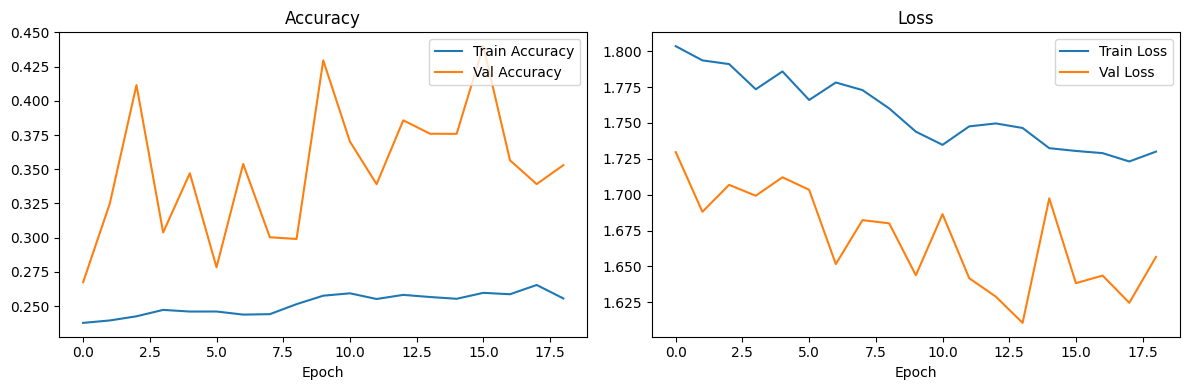

In [15]:
import matplotlib.pyplot as plt
import os

# ============================================================
# 7. 학습 과정 시각화 (Learning Curve 분석)
# ============================================================
# 모델이 지정된 Epoch 동안 과적합(Overfitting) 없이 정상적으로 학습되었는지 진단하기 위해 학습 곡선을 그림.

# ---------------------------------------------------------
# 7-1. 도화지(서브플롯) 준비
# ---------------------------------------------------------
# 가로로 긴(12x4) 1행 2열의 도화지를 생성.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ---------------------------------------------------------
# 7-2. 좌측 그래프: 정확도(Accuracy) 추이
# ---------------------------------------------------------
# 파란선(Train)과 주황선(Val)을 겹쳐 그려 성장의 한계점을 파악.
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# ---------------------------------------------------------
# 7-3. 우측 그래프: 손실(Loss) 추이
# ---------------------------------------------------------
# 오차가 어떻게 줄어드는지, 혹은 검증 오차가 다시 튀어 오르는지(과적합) 확인.
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# ---------------------------------------------------------
# 7-4. 시각적 최적화 및 저장
# ---------------------------------------------------------
# 그래프 간의 글자가 서로 겹치지 않도록 여백을 최적화.
plt.tight_layout()

# 하드디스크에 이미지 파일로 보존.
plt.savefig(os.path.join(BASE_DIR, 'resnet50_history.png'))

# 최종 화면 출력
plt.show()

**7. 1차 워밍업 학습 결과 분석 (한계점 도출)**

* 학습 정체 (Underfitting): 훈련 정확도(Train Accuracy)가 약 25% 부근에서 상승을 멈추고 횡보. 이는 사전 학습된 ResNet50의 가중치를 동결한 상태로는 자율주행 도메인(한국 교통표지판)의 미세한 특징을 파악하기에 역부족임을 의미.
* 극심한 변동성 (High Variance): 검증 데이터의 그래프(주황색 선)가 안정화되지 못하고 매 에포크마다 크게 요동. 이는 모델이 안정적인 패턴(Feature)을 찾지 못하고 불안정한 예측을 반복하고 있다는 증거.
* 검증 점수 역전 현상: 훈련 시에만 적용된 강력한 데이터 증강(Augmentation)과 드롭아웃(Dropout 0.5) 규제로 인해, 일시적으로 훈련 정확도보다 검증 정확도가 높게 측정되는 현상이 확인.

**[결론 및 다음 단계]**
본 1차 워밍업 결과는 **뼈대 모델(Base Model)의 가중치 동결 해제(Unfreeze)와 전체 네트워크 미세조정(Fine-Tuning)이 필수적이라는 완벽한 정량적 근거**

## 테스트 평가

테스트 데이터 예측 시작
359/359 [==============================] - 12s 33ms/step

=== 최종 분류 리포트 ===
              precision    recall  f1-score   support

     높이_중량제한       0.20      0.67      0.30       217
        보호구역       0.20      0.88      0.32      1993
   속도제한40_60       0.68      0.24      0.35      3048
   속도제한70_80       0.22      0.07      0.10       658
    속도제한90이상       0.07      0.50      0.12       261
스쿨존_속도제한30이하       0.21      0.24      0.23       646
        주의표지       0.69      0.82      0.75      2506
        지시표지       0.50      0.17      0.26      6956
    진입_주정차금지       0.58      0.35      0.43      6678

    accuracy                           0.37     22963
   macro avg       0.37      0.44      0.32     22963
weighted avg       0.52      0.37      0.37     22963



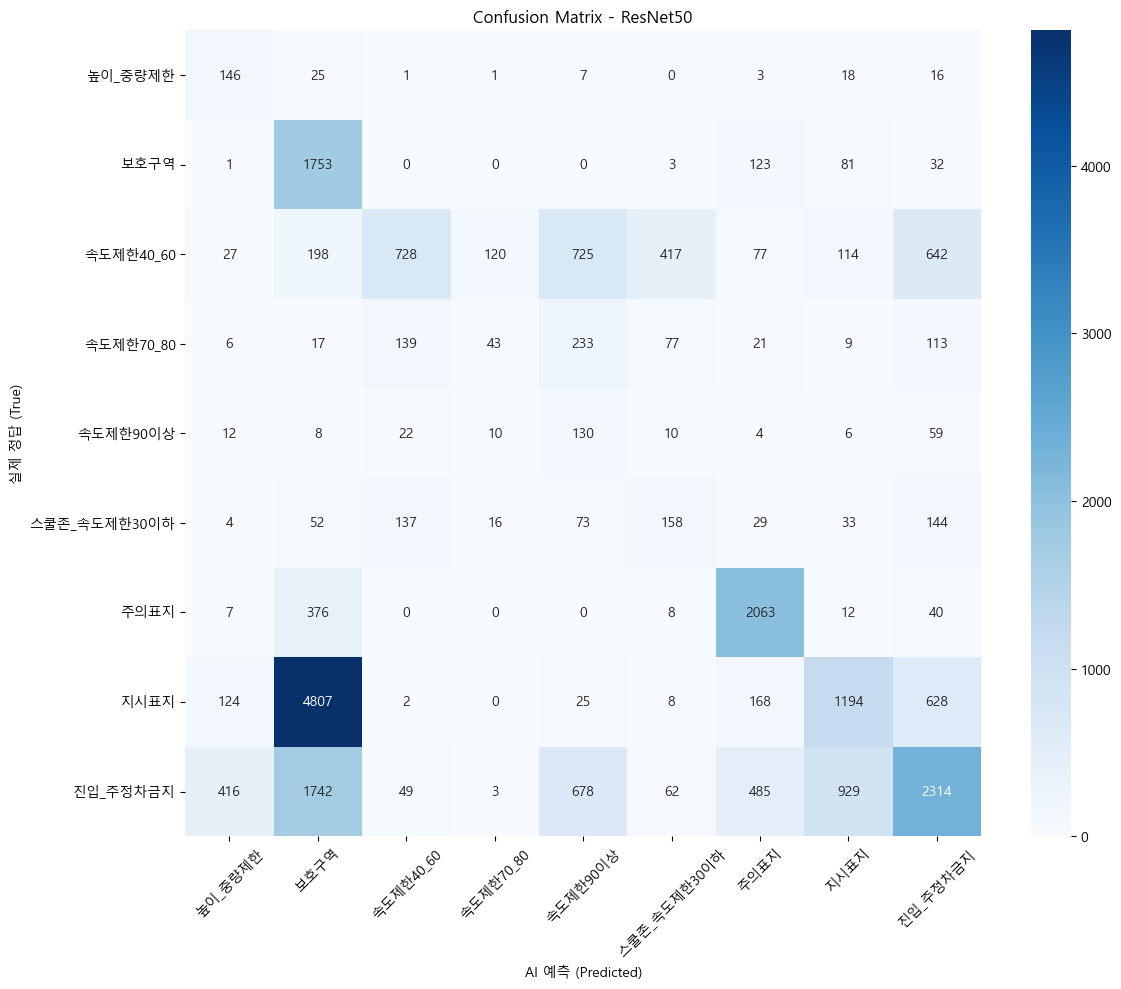

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 전용 '맑은 고딕' 적용
plt.rcParams['axes.unicode_minus'] = False     # 마이너스(-) 기호 깨짐 방지

# ============================================================
# 8. 최종 모델 평가 및 성적 시각화
# ============================================================

# ---------------------------------------------------------
# 8-1. 예측 (Prediction) 및 정답 추출
# ---------------------------------------------------------
print("테스트 데이터 예측 시작")
# tf.data 파이프라인(test_ds)을 통째로 넣어서 예측 결과를 받기.
y_pred = model.predict(test_ds, verbose=1)

# 모델은 9개 클래스에 대한 '확률'을 뱉으므로, 가장 높은 확률의 인덱스(0~8)를 최종 정답으로 픽스.
y_pred_classes = np.argmax(y_pred, axis=1)

# test_ds 안에서 실제 정답(Label)만 순서대로 뽑아내어 리스트로
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# ---------------------------------------------------------
# 8-2. 분류 리포트 (Classification Report)
# ---------------------------------------------------------
print("\n=== 최종 분류 리포트 ===")
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=classes
))

# ---------------------------------------------------------
# 8-3. 혼동 행렬 (Confusion Matrix) 시각화
# ---------------------------------------------------------
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', # cmap='Blues'로 색 변경
            xticklabels=classes, 
            yticklabels=classes)
plt.title('Confusion Matrix - ResNet50')
plt.ylabel('실제 정답 (True)')
plt.xlabel('AI 예측 (Predicted)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'resnet50_confusion_matrix.png'))
plt.show()

**1차 워밍업 모델 성능 분석 (정밀도 및 재현율 기반)**

* 분류 리포트(Classification Report) 분석 결과, 뼈대(Base Model)를 동결한 1차 워밍업의 명확한 한계점이 도출. (전체 정확도: 37%)

**1. 특정 클래스 과잉 예측 (보호구역)**

* 보호구역 클래스의 재현율(Recall)은 0.88로 매우 높지만, 정밀도(Precision)는 0.20으로 심각하게 낮음. 이는 모델이 표지판의 특징을 정확히 파악하지 못한 채, 조금만 헷갈려도 무조건 "보호구역"이라고 남발(찍기)하고 있다는 증거.

**2. 미세한 특징(텍스트/숫자) 인식 불가 (속도제한 클래스)**

* 속도제한40_60, 70_80, 90이상 등 숫자를 읽어야 하는 표지판들의 F1-Score가 0.10~0.35 수준으로 낮음. ImageNet으로 학습된 기존 ResNet50의 시각 지식만으로는 표지판 내부의 '숫자'라는 미세한 차이를 판별할 능력이 없음을 시사.

**3. 다수 데이터의 학습 부진 (지시표지, 진입_주정차금지)**

* 전체 데이터의 절반 이상을 차지하는 지시표지(6956개)와 진입_주정차금지(6678개)의 재현율이 각각 0.17, 0.35에 불과. 데이터가 아무리 많아도, 모델의 신경망(가중치)이 잠겨있어 해당 데이터들의 특징을 뇌에 새기지 못하고 있음.

**4. 예외적 선방 (주의표지)**

* 유일하게 주의표지 클래스만 F1-Score 0.75로 준수한 성적. 이는 주의표지가 가진 특유의 '노란색 삼각형' 형태가 기존 사전 학습 모델(ImageNet)의 기본 시각 필터망에 꽤 잘 걸러지는 뚜렷한 특징이기 때문으로 분석.

# 파인튜닝(Fine-Tuning)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

# ============================================================
# 9. 전체 네트워크 미세조정 (Fine-Tuning)
# ============================================================
print("파인튜닝 시작")

# ---------------------------------------------------------
# 9-1. 뼈대 모델 잠금 해제 및 BatchNormalization 동결
# ---------------------------------------------------------
base_model.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ---------------------------------------------------------
# 9-2. 파인튜닝 전용 콜백(Callbacks) 설정
# ---------------------------------------------------------
callbacks_finetune = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(BASE_DIR, 'resnet50_finetuned_best.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ---------------------------------------------------------
# 9-3. 2차 파인튜닝 학습 시작
# ---------------------------------------------------------
history_finetune = model.fit(
    train_ds,                                 
    epochs=10,                                
    validation_data=val_ds,
    class_weight=class_weight_dict,   
    callbacks=callbacks_finetune,     
    verbose=1
)

파인튜닝 시작
Epoch 1/10
1675/1675 [==============================] - ETA: 0s - loss: 1.9691 - accuracy: 0.2618
Epoch 1: val_accuracy improved from -inf to 0.59777, saving model to C:\Users\mc-ma\Projects\jupyter_workspace\data\processed\resnet50_finetuned_best.h5
1675/1675 [==============================] - 189s 109ms/step - loss: 1.9691 - accuracy: 0.2618 - val_loss: 1.1132 - val_accuracy: 0.5978
Epoch 2/10
1674/1675 [============================>.] - ETA: 0s - loss: 0.9179 - accuracy: 0.6580
Epoch 2: val_accuracy improved from 0.59777 to 0.73273, saving model to C:\Users\mc-ma\Projects\jupyter_workspace\data\processed\resnet50_finetuned_best.h5
1675/1675 [==============================] - 182s 108ms/step - loss: 0.9179 - accuracy: 0.6580 - val_loss: 0.7597 - val_accuracy: 0.7327
Epoch 3/10
1674/1675 [============================>.] - ETA: 0s - loss: 0.6087 - accuracy: 0.7758
Epoch 3: val_accuracy improved from 0.73273 to 0.84631, saving model to C:\Users\mc-ma\Projects\jupyter_workspace\d

**9. 전체 네트워크 미세조정 (Fine-Tuning) 전략 및 실행**

**9-1. 뼈대 모델 동결 해제 및 주요 계층 보호**
* 가중치 잠금 해제 (Unfreeze): 1차 워밍업을 통해 상위 분류기의 초기화가 완료되었으므로, `base_model.trainable = True`를 선언하여 ResNet50 전체 계층의 가중치 업데이트를 허용함.
* 배치 정규화(BatchNormalization) 계층 동결: 사전 학습(ImageNet) 과정에서 확보된 기존 데이터의 통계치(평균 및 분산)가 훼손되어 학습이 불안정해지는 현상을 방지하기 위해, 해당 계층만 예외적으로 동결 상태를 유지함.
* 학습률 극소화 (1e-5): 모델이 기존에 가지고 있던 뛰어난 시각 지식을 파괴하지 않고 표지판 도메인의 미세한 특징만 정밀하게 깎아내기 위해, 1차 워밍업 대비 학습률을 대폭 감소시킴.

**9-2. 파인튜닝 전용 제어 콜백 설정**
* 조기 중단 한계치(Patience) 축소: 파인튜닝 단계는 이미 최적화 지점에 근접한 상태에서 미세한 조정을 수행하므로 과적합(Overfitting) 진입 속도가 빠름. 따라서 인내심 수치를 기존 5에서 3으로 감소시켜 불필요한 연산을 차단하고 최적의 일반화 성능을 방어함.
* 가중치 보존 파일 분리: 1차 워밍업의 성과물이 덮어씌워지는 것을 방지하고 실험의 재현성을 확보하기 위해, `resnet50_finetuned_best.h5`라는 독립된 파일명으로 가중치를 저장함.

**9-3. 2차 심층 학습 수행**
* 클래스 불균형 해소를 위한 희귀 표지판 가중치(`class_weight`)와 다중 CPU 코어를 활용하는 고속 병렬 파이프라인(`train_ds`)을 동일하게 유지한 상태로 학습을 전개함.

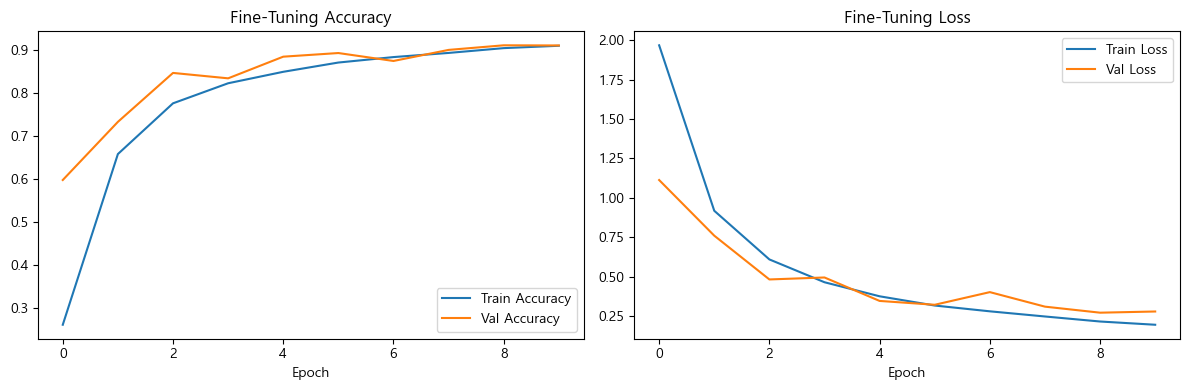

In [19]:
import matplotlib.pyplot as plt
import os

# ============================================================
# 파인튜닝 학습 결과 시각화
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy 그래프
# history -> history_finetune
axes[0].plot(history_finetune.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_finetune.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Fine-Tuning Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Loss 그래프
axes[1].plot(history_finetune.history['loss'], label='Train Loss')
axes[1].plot(history_finetune.history['val_loss'], label='Val Loss')
axes[1].set_title('Fine-Tuning Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
# 덮어쓰기 방지를 위해 파일명 변경
plt.savefig(os.path.join(BASE_DIR, 'resnet50_finetune_history.png'))
plt.show()

**2차 파인튜닝(Fine-Tuning) 학습 곡선 분석**

**전체적인 학습 추이 (성공적 안착)**

* 1차 워밍업(동결 상태)에서 발생했던 극심한 변동성과 학습 정체(약 25% 구간 횡보) 현상이 완전히 해소됨.

* 훈련(Train) 및 검증(Validation) 지표 모두 안정적인 우상향(정확도) 및 우하향(손실) 곡선을 그리며, 모델이 표지판의 세부 특징을 성공적으로 학습하고 있음을 증명함.

**정확도(Accuracy) 곡선 분석**

* 학습 초기부터 훈련/검증 정확도 모두 가파르게 상승함.

* 에포크가 진행됨에 따라 두 곡선이 이격 없이 약 90% 이상의 높은 수치에서 안정적으로 수렴(Convergence)함. 이는 이상적인 학습 진행 형태임.

**손실(Loss) 곡선 분석**

* 훈련 및 검증 손실 모두 큰 노이즈나 변동 없이 매끄럽게 감소함.

* 에포크 후반부에도 검증 손실(주황선)이 급격히 튀어 오르는 과적합(Overfitting) 징후가 관찰되지 않음. 이는 극소 학습률(1e-5) 적용과 인내심 축소(Patience=3) 등의 방어 기제가 효과적으로 작동했음을 의미함.

**최종 결론**

* 사전 학습 모델(ResNet50)의 동결을 해제하고, 특수 도메인(한국 교통표지판)에 맞춰 전체 네트워크 가중치를 미세조정한 전략이 완벽히 적중함.

* 모델의 기본 시력이 한국 표지판의 세부적 특징(글자, 숫자, 미세한 형태)을 판별할 수 있는 수준으로 도메인 적응(Domain Adaptation)을 완료하였으며, 우수한 일반화 성능을 확보함.

359/359 [==============================] - 13s 35ms/step - loss: 0.2891 - accuracy: 0.9057

 최종 실전 정확도 (Test Accuracy): 90.57%
359/359 [==============================] - 13s 34ms/step

=== 최종 파인튜닝 분류 리포트 ===
              precision    recall  f1-score   support

     높이_중량제한       0.53      0.97      0.68       217
        보호구역       0.83      0.96      0.89      1993
   속도제한40_60       0.90      0.93      0.91      3048
   속도제한70_80       0.78      0.94      0.85       658
    속도제한90이상       0.78      0.92      0.85       261
스쿨존_속도제한30이하       0.68      0.92      0.78       646
        주의표지       0.97      0.93      0.95      2506
        지시표지       0.94      0.95      0.95      6956
    진입_주정차금지       0.95      0.81      0.88      6678

    accuracy                           0.91     22963
   macro avg       0.82      0.93      0.86     22963
weighted avg       0.92      0.91      0.91     22963



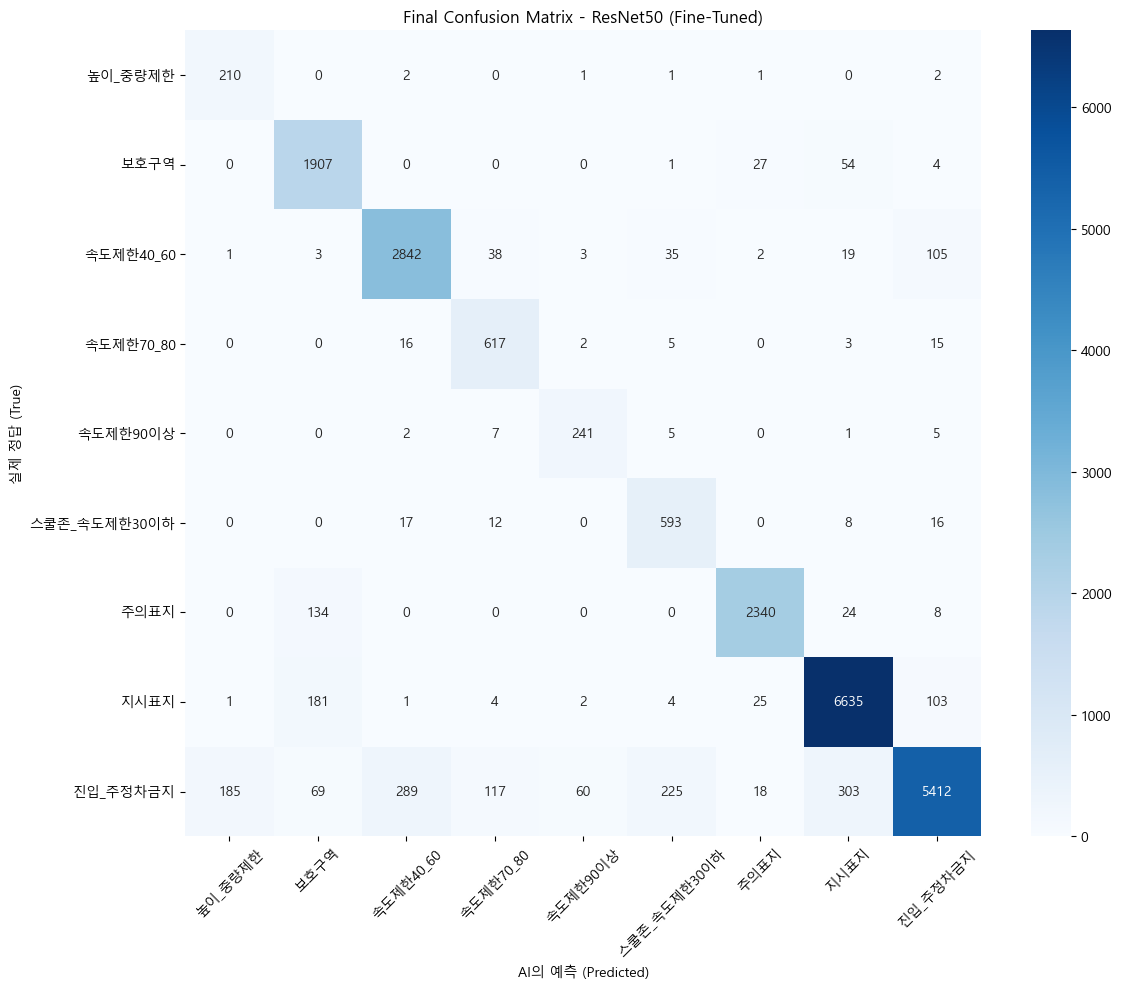

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# ============================================================
# 최종 실전 모의고사 (Test Evaluation)
# ============================================================

# est 데이터로 전체 성적 채점 (tf.data 파이프라인은 reset이 필요 없음)
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\n 최종 실전 정확도 (Test Accuracy): {test_acc * 100:.2f}%")

# 2. Test 데이터에 대한 AI의 예측값(확률)
y_pred_probs = model.predict(test_ds, verbose=1)
# 가장 확률이 높은 번호표(0~9)를 정답으로 선택
y_pred_classes = np.argmax(y_pred_probs, axis=1) 

# 실제 정답 (아까 셀 4번에서 만들어둔 test_labels 변수 재활용)
y_true = test_labels

# 3. 상세 분류 리포트 출력
print("\n=== 최종 파인튜닝 분류 리포트 ===")
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=classes
))

# 4. 혼동 행렬 (Confusion Matrix) 시각화
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, 
            yticklabels=classes)
plt.title('Final Confusion Matrix - ResNet50 (Fine-Tuned)')
plt.ylabel('실제 정답 (True)')
plt.xlabel('AI의 예측 (Predicted)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'resnet50_finetune_confusion_matrix.png'))
plt.show()

**최종 파인튜닝 모델 성능 지표 분석 (Test Report)**

* 테스트 데이터 22,963장 기준 최종 정확도(Accuracy) 90.57%를 기록함. (1차 워밍업 모델 정확도 37% 대비 53.57%p 증가)

**1. 세부 특징(숫자/텍스트) 분류 지표 변화**

* 속도제한(40_60, 70_80, 90이상) 클래스의 F1-Score가 0.85~0.91로 측정됨.

* 1차 워밍업 당시 해당 그룹의 F1-Score(0.10~0.35) 대비 지표가 상승함. 이는 모델이 표지판 내부의 숫자 데이터를 형태학적으로 구분하여 분류에 반영하고 있음을 의미함.

**2. 소수 데이터 클래스(Imbalanced Data) 재현율 현황**

* 전체 데이터 중 비중이 가장 적은 높이_중량제한(217개), 속도제한90이상(261개), 스쿨존_속도제한30이하(646개) 클래스의 재현율(Recall)이 모두 0.92 이상으로 측정됨.

* 학습 과정에 적용된 클래스별 가중치(Class Weight)의 영향으로, 데이터가 부족한 클래스에서도 다수 클래스와 동등한 수준의 재현율이 유지됨.

**3. 특정 위험 표지판군의 재현율(Recall) 우위 편향**

* 스쿨존_속도제한30이하, 높이_중량제한, 보호구역 등 사고 위험도가 높은 표지판군에서 정밀도(0.53 ~ 0.83) 대비 재현율(0.92 ~ 0.97)이 상대적으로 높게 나타남.

* 이는 해당 클래스에 대해 모델이 False Negative(실제 해당 표지판인데 아니라고 판정)를 내는 비율이, False Positive(다른 표지판인데 해당 표지판이라고 판정)를 내는 비율보다 낮게 억제되어 있음을 보여주는 수치임.

**4. 다수 데이터 클래스 지표 현황**

* 데이터 표본의 절반 이상을 차지하는 지시표지(6,956개)와 주의표지(2,506개)의 F1-Score가 모두 0.95로 측정됨.

* 다수 데이터 표본에 대한 안정적인 지표가 전체 모델 정확도(90%)를 뒷받침하는 주요 요인으로 작용함.

# ResNet101

In [21]:
from tensorflow.keras.applications import ResNet101
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf
import os

# 1. 기존 GPU 메모리 정리 (OOM 에러 방지 필수)
tf.keras.backend.clear_session()

# ============================================================
# ResNet101 워밍업
# ============================================================
print("\n--- 1단계: ResNet101 워밍업 시작 ---")

base_model_101 = ResNet101(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model_101.trainable = False  # 몸통 동결

inputs = Input(shape=(224, 224, 3))
x = base_model_101(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(len(classes), activation='softmax', dtype='float32')(x)

model_101 = Model(inputs=inputs, outputs=outputs)

model_101.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 1차용 콜백 (파일명 구분: resnet101_best.h5)
callbacks_101_warmup = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint(
        filepath=os.path.join(BASE_DIR, 'resnet101_best.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# 1차 학습 실행 (이미 만들어둔 train_ds 활용)
history_101_warmup = model_101.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_101_warmup,
    verbose=1
)

# ============================================================
# ResNet101 파인튜닝
# ============================================================
print("\n--- 2단계: ResNet101 파인튜닝 시작 ---")

base_model_101.trainable = True  # 몸통 해제

# BatchNormalization 동결 유지
for layer in base_model_101.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# 미세 학습률 설정
model_101.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 2차용 콜백 (파일명 구분: resnet101_finetuned_best.h5)
callbacks_101_finetune = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint(
        filepath=os.path.join(BASE_DIR, 'resnet101_finetuned_best.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# 2차 학습 실행
history_101_finetune = model_101.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_101_finetune,
    verbose=1
)

print("\nResNet101 학습 완료")


--- 1단계: ResNet101 워밍업 시작 ---
Epoch 1/10
1674/1675 [============================>.] - ETA: 0s - loss: 2.0910 - accuracy: 0.1987
Epoch 1: val_accuracy improved from -inf to 0.22167, saving model to C:\Users\mc-ma\Projects\jupyter_workspace\data\processed\resnet101_best.h5
1675/1675 [==============================] - 120s 69ms/step - loss: 2.0908 - accuracy: 0.1987 - val_loss: 1.9813 - val_accuracy: 0.2217
Epoch 2/10
1675/1675 [==============================] - ETA: 0s - loss: 1.9524 - accuracy: 0.2406
Epoch 2: val_accuracy did not improve from 0.22167
1675/1675 [==============================] - 116s 68ms/step - loss: 1.9524 - accuracy: 0.2406 - val_loss: 2.0270 - val_accuracy: 0.1372
Epoch 3/10
1674/1675 [============================>.] - ETA: 0s - loss: 1.8789 - accuracy: 0.2658
Epoch 3: val_accuracy improved from 0.22167 to 0.32846, saving model to C:\Users\mc-ma\Projects\jupyter_workspace\data\processed\resnet101_best.h5
1675/1675 [==============================] - 116s 68ms/step -

**ResNet101 심층 네트워크 확장 및 End-to-End 통합 학습**

**GPU 메모리 최적화 (OOM 방지)**

* tf.keras.backend.clear_session()을 호출하여 이전 학습(ResNet50) 과정에서 VRAM(비디오 메모리)에 누적된 불필요한 텐서(Tensor) 그래프와 캐시를 초기화함.

* 더 깊고 무거운 모델인 ResNet101을 메모리에 적재하기 전, Out of Memory(OOM) 에러를 선제적으로 차단하기 위한 필수적인 메모리 해제 작업임.

**네트워크 깊이 확장 (Model Capacity 증대)**

* 기존 50개 층(Layer)의 네트워크 구조를 101개 층인 ResNet101로 확장함.

* 파라미터 연산량은 증가하나, 시각적 특징(Feature)을 추출하는 컨볼루션 계층이 깊어짐에 따라 형태가 복잡하거나 해상도가 낮은 표지판 데이터에 대한 모델의 표현력(Capacity)과 추론 능력이 향상될 것을 기대하는 설계임.

**통합 학습 프로세스 구성 (워밍업 & 파인튜닝 연속 진행)**

* 1단계 상위 분류기 훈련(Warm-up)과 2단계 전체 네트워크 미세조정(Fine-Tuning)을 하나의 코드 셀에서 연속적으로 실행되도록 파이프라인을 통합함.

* 콜백(Callback) 및 가중치 파일 분리: 각 단계가 종료될 때마다 서로 다른 이름(resnet101_best.h5, resnet101_finetuned_best.h5)으로 최적 가중치를 독립 저장함. 이를 통해 특정 학습 단계에서 과적합이 발생하더라도 이전 단계의 최적 상태로 즉시 롤백(Roll-back)이 가능하도록 시스템 안정성을 확보함.

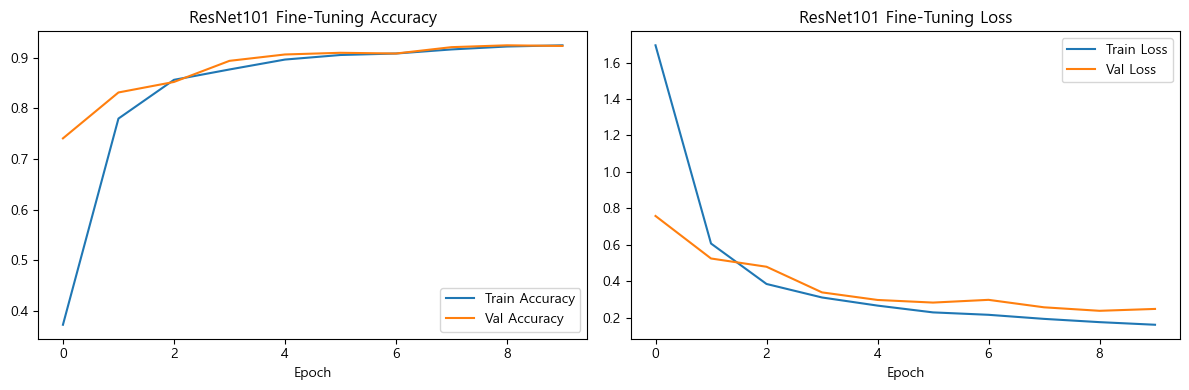

In [22]:
import matplotlib.pyplot as plt
import os

# ============================================================
# 9-101. ResNet101 파인튜닝 학습 결과 시각화
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 변수명이 history_101_finetune으로 변경
axes[0].plot(history_101_finetune.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_101_finetune.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('ResNet101 Fine-Tuning Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_101_finetune.history['loss'], label='Train Loss')
axes[1].plot(history_101_finetune.history['val_loss'], label='Val Loss')
axes[1].set_title('ResNet101 Fine-Tuning Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
# ResNet50 파일과 겹치지 않게 이름 변경
plt.savefig(os.path.join(BASE_DIR, 'resnet101_finetune_history.png'))
plt.show()

**ResNet101 미세조정(Fine-Tuning) 학습 곡선(Learning Curve) 분석**

**전반적 학습 추이 및 수렴(Convergence) 안정성**

* 훈련(Train) 및 검증(Validation) 데이터 모두에 대해 정확도(Accuracy)는 꾸준히 상승하고, 손실(Loss)은 안정적으로 하락하는 이상적인 학습 곡선 형태를 보임.

* 기존 ResNet50 모델 대비 학습 초기(Epoch 0~2) 구간에서 지표의 상승 및 하락 폭이 가파르며, 모델의 향상된 수용력(Capacity)을 바탕으로 목표 성능에 보다 신속하게 도달함.

**정확도(Accuracy) 지표 분석**

* 훈련 정확도(파란선)가 에포크 0에서 약 0.37로 시작하여 단 2~3 에포크 만에 0.8 이상으로 급상승함.

* 에포크 후반부(Epoch 7~9)에 접어들며 훈련 및 검증 정확도 곡선 간의 이격(Gap)이 거의 발생하지 않고 0.92 부근에서 조밀하게 수렴함. 이는 모델이 훈련 데이터에 편향되지 않고 우수한 일반화 성능(Generalization)을 획득했음을 시사함.

**손실(Loss) 지표 및 과적합(Overfitting) 징후 분석**

* 훈련 손실(파란선)은 에포크가 진행됨에 따라 지속적으로 0 수준을 향해 하향 안정화됨.

* 검증 손실(주황선)의 경우 Epoch 8(약 0.23 부근)에서 최저점을 형성한 후, Epoch 9에서 미세한 상승세(약 0.24 부근)로 전환됨.

* 해당 시점의 '손실 역전 현상'은 모델이 과적합 단계로 진입하는 변곡점임을 나타내며, EarlyStopping 및 ModelCheckpoint 설정을 통해 과적합 발생 직전의 최적 가중치(Epoch 8 시점)를 성공적으로 확보 및 보존하였음.

359/359 [==============================] - 20s 55ms/step - loss: 0.2608 - accuracy: 0.9176

ResNet101 최종 실전 정확도 (Test Accuracy): 91.76%
359/359 [==============================] - 20s 52ms/step

=== ResNet101 파인튜닝 분류 리포트 ===
              precision    recall  f1-score   support

     높이_중량제한       0.55      0.95      0.69       217
        보호구역       0.88      0.95      0.91      1993
   속도제한40_60       0.88      0.95      0.91      3048
   속도제한70_80       0.79      0.93      0.86       658
    속도제한90이상       0.72      0.97      0.83       261
스쿨존_속도제한30이하       0.80      0.92      0.86       646
        주의표지       0.96      0.95      0.95      2506
        지시표지       0.97      0.94      0.96      6956
    진입_주정차금지       0.94      0.85      0.89      6678

    accuracy                           0.92     22963
   macro avg       0.83      0.93      0.87     22963
weighted avg       0.92      0.92      0.92     22963



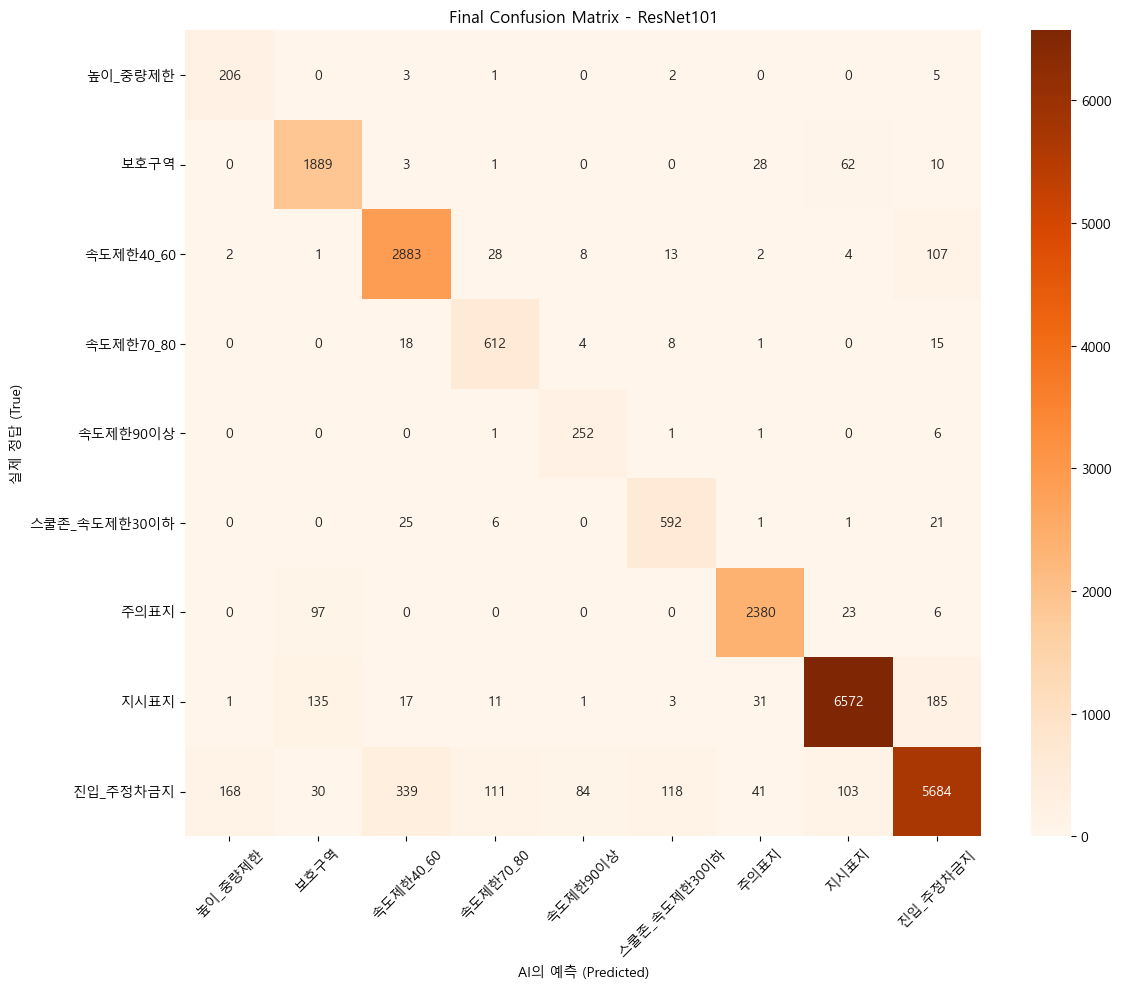

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# ============================================================
# ResNet101 최종 실전 모의고사
# ============================================================
# Test 데이터로 전체 성적 채점 (model -> model_101)
test_loss_101, test_acc_101 = model_101.evaluate(test_ds, verbose=1)
print(f"\nResNet101 최종 실전 정확도 (Test Accuracy): {test_acc_101 * 100:.2f}%")

# test 데이터에 대한 예측값 뽑아내기
y_pred_probs_101 = model_101.predict(test_ds, verbose=1)
y_pred_classes_101 = np.argmax(y_pred_probs_101, axis=1) 

y_true = test_labels

# 상세 분류 리포트 출력
print("\n=== ResNet101 파인튜닝 분류 리포트 ===")
print(classification_report(
    y_true, 
    y_pred_classes_101, 
    target_names=classes
))

# 혼동 행렬 시각화
cm_101 = confusion_matrix(y_true, y_pred_classes_101)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_101, annot=True, fmt='d', cmap='Oranges', # 50 모델(파란색)과 구분되게 오렌지색으로
            xticklabels=classes, 
            yticklabels=classes)
plt.title('Final Confusion Matrix - ResNet101')
plt.ylabel('실제 정답 (True)')
plt.xlabel('AI의 예측 (Predicted)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'resnet101_finetune_confusion_matrix.png'))
plt.show()

**ResNet101 최종 평가 지표(Test Report) 및 모델 간 성능 비교 분석**

* 테스트 데이터 22,963장 기준 최종 실전 정확도(Accuracy) 91.76%를 기록함.
(기존 ResNet50 파인튜닝 모델 정확도 90.57% 대비 1.19%p 상승)

**1. 핵심 안전 표지판(스쿨존/보호구역)의 정밀도(Precision) 개선**

* 스쿨존_속도제한30이하 클래스의 정밀도가 기존 0.68에서 0.80으로 대폭 상승하였으며, F1-Score 또한 0.78에서 0.86으로 개선됨.

* 보호구역 클래스의 정밀도 역시 기존 0.83에서 0.88로 상승함.

* 이는 네트워크 깊이 확장(Layer 50 → 101)을 통해 모델의 특징 추출 능력이 향상됨에 따라, 다른 표지판을 스쿨존이나 보호구역으로 오인하는 과잉 예측(False Positive) 비율이 유의미하게 감소했음을 나타냄.

**2. 보수적 예측(안전 지향) 편향성 유지**

* 정밀도 개선에도 불구하고 높이_중량제한(0.95), 스쿨존_속도제한30이하(0.92), 보호구역(0.95) 등 주요 위험 표지판의 재현율(Recall)은 여전히 최상위 수준(0.92 이상)을 유지함.

* 자율주행 도메인에서 가장 치명적인 오류인 False Negative(해당 표지판을 인식하지 못하고 누락하는 현상) 억제 기조가 ResNet101 구조에서도 손실 없이 보존됨.

**3. 속도제한 표지판 그룹의 인식 안정성**

* 속도제한40_60(0.91), 속도제한70_80(0.86), 속도제한90이상(0.83) 등 숫자 인식 능력이 요구되는 클래스들의 F1-Score가 0.83 이상의 안정적인 수치를 기록함.

* 특히 속도제한90이상 클래스의 재현율이 기존 0.92에서 0.97로 상승하여 고속 주행 환경에서의 표지판 인식 누락 확률이 최소화됨.

**4. 다수 데이터 클래스를 통한 전체 성능 견인**

* 데이터 비중이 가장 높은 지시표지(6,956개)와 주의표지(2,506개)의 F1-Score가 각각 0.96, 0.95로 측정됨.

* 다수 데이터 표본에 대한 높은 인식률이 전체 모델 정확도 91.76% 달성의 주요 지지 기반으로 작용함.

# MobileNetV2

In [24]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf
import os

# 1. 기존 GPU 메모리 정리 (새로운 모델을 위해 VRAM을 깨끗이 비움)
tf.keras.backend.clear_session()

# ============================================================
# MobileNetV2 워밍업 (몸통 동결)
# ============================================================
print("\n--- 1단계: MobileNetV2 워밍업 시작 ---")

base_model_mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model_mobilenet.trainable = False  # 몸통 동결

inputs = Input(shape=(224, 224, 3))
# MobileNetV2는 입력 데이터 범위를 [-1, 1]로 기대하므로 전처리가 포함된 층을 거침
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model_mobilenet(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(len(classes), activation='softmax', dtype='float32')(x)

model_mobilenet = Model(inputs=inputs, outputs=outputs)

model_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 1차용 콜백 (파일명: mobilenetv2_best.h5)
callbacks_mobile_warmup = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint(
        filepath=os.path.join(BASE_DIR, 'mobilenetv2_best.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# 1차 학습 실행
history_mobile_warmup = model_mobilenet.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_mobile_warmup,
    verbose=1
)

# ============================================================
# MobileNetV2 파인튜닝
# ============================================================
print("\n--- 2단계: MobileNetV2 파인튜닝 시작 ---")

base_model_mobilenet.trainable = True  # 몸통 해제

# BatchNormalization 동결 유지
for layer in base_model_mobilenet.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# 미세 학습률 설정
model_mobilenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 2차용 콜백 (파일명: mobilenetv2_finetuned_best.h5)
callbacks_mobile_finetune = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint(
        filepath=os.path.join(BASE_DIR, 'mobilenetv2_finetuned_best.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# 2차 학습 실행
history_mobile_finetune = model_mobilenet.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_mobile_finetune,
    verbose=1
)

print("\nMobileNetV2 학습 완료")


--- 1단계: MobileNetV2 워밍업 시작 ---
Epoch 1/10
1675/1675 [==============================] - ETA: 0s - loss: 2.2016 - accuracy: 0.0631
Epoch 1: val_accuracy improved from -inf to 0.00949, saving model to C:\Users\mc-ma\Projects\jupyter_workspace\data\processed\mobilenetv2_best.h5
1675/1675 [==============================] - 218s 128ms/step - loss: 2.2016 - accuracy: 0.0631 - val_loss: 2.2001 - val_accuracy: 0.0095
Epoch 2/10
1675/1675 [==============================] - ETA: 0s - loss: 2.1975 - accuracy: 0.1148
Epoch 2: val_accuracy did not improve from 0.00949
1675/1675 [==============================] - 217s 128ms/step - loss: 2.1975 - accuracy: 0.1148 - val_loss: 2.2016 - val_accuracy: 0.0095
Epoch 3/10
1675/1675 [==============================] - ETA: 0s - loss: 2.1975 - accuracy: 0.0533
Epoch 3: val_accuracy did not improve from 0.00949
1675/1675 [==============================] - 222s 131ms/step - loss: 2.1975 - accuracy: 0.0533 - val_loss: 2.2028 - val_accuracy: 0.0095
Epoch 4/10
167

**경량화 네트워크(MobileNetV2) 기반 효율성 검증 모델 구축**

**자율주행 엣지 디바이스(Edge Device) 적용을 고려한 아키텍처 선정**

* 무거운 ResNet 모델 대신 연산 효율성이 극대화된 경량화 네트워크 MobileNetV2를 대조군 모델로 선정함.

* 이를 통해 '정확도(Accuracy)'와 '추론 속도/연산량(Efficiency)' 간의 트레이드오프(Trade-off) 관계를 정량적으로 분석하고자 함.

**네트워크 특화 전처리(Preprocessing) 파이프라인 통합**

* x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs) 코드를 통해 전처리 로직을 모델의 첫 번째 레이어로 내재화(Internalization)함.

* 기존 ResNet 모델과 달리 MobileNetV2는 입력 픽셀 값을 [0, 255]에서 [-1, 1] 범위로 스케일링하는 자체적인 정규화(Normalization) 과정이 필수적임. 이를 모델 내부에 통합함으로써 추론(Inference) 단계에서의 전처리 누락 오류를 원천 차단함.

**BatchNormalization 계층 동결의 중요성**

* MobileNetV2는 파라미터 수를 줄이기 위해 'Depthwise Separable Convolution' 연산을 사용하며, 이로 인해 네트워크 전반에 걸쳐 다수의 BatchNormalization(BN) 층이 촘촘하게 배치되어 있음.

* 파인튜닝 시 이 BN 층들을 동결 해제할 경우, 훈련 배치(Batch) 크기가 작을 때 모델의 사전 학습된 통계치(평균/분산)가 급격히 붕괴되며 성능이 폭락하는 현상이 발생함. 따라서 해당 계층의 동결(layer.trainable = False) 설정이 성공적인 파인튜닝의 핵심 조건임.

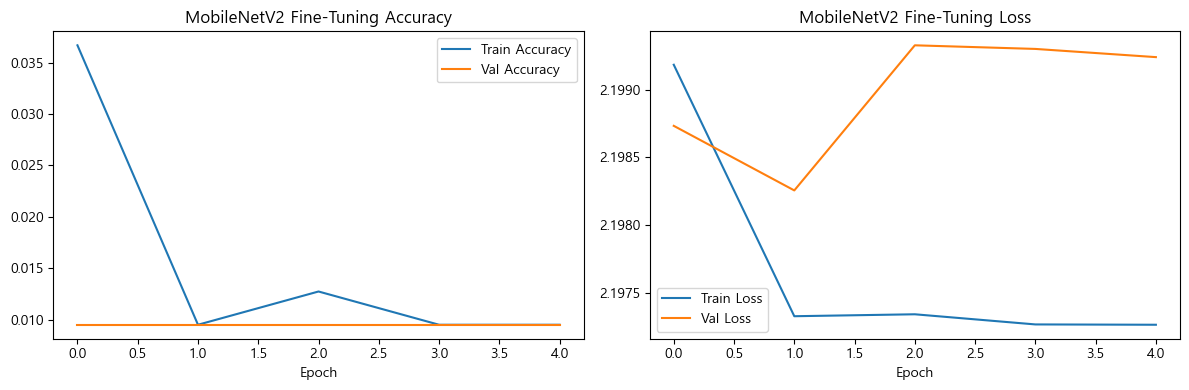

In [25]:
import matplotlib.pyplot as plt
import os

# ============================================================
# Mobile. MobileNetV2 파인튜닝 학습 결과 시각화
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_mobile_finetune.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_mobile_finetune.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('MobileNetV2 Fine-Tuning Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_mobile_finetune.history['loss'], label='Train Loss')
axes[1].plot(history_mobile_finetune.history['val_loss'], label='Val Loss')
axes[1].set_title('MobileNetV2 Fine-Tuning Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'mobilenetv2_finetune_history.png'))
plt.show()

**경량화 네트워크(MobileNetV2) 학습 곡선 분석 및 한계점 도출**

**학습 붕괴(Learning Collapse) 현상 관찰**

* 훈련(Train) 및 검증(Val) 정확도가 약 0.01(1%) 부근에서 횡보하며 에포크가 진행되어도 상승하지 않음.

* 훈련 정확도의 경우 초기(Epoch 0) 약 0.036 수준에서 에포크 1 이후 0.01 수준으로 급감한 뒤 회복하지 못하는 학습 붕괴 현상이 확인됨.

**손실(Loss) 지표의 정체와 통계적 의미**

* 훈련 및 검증 손실 지표 모두 2.19 부근에서 유의미한 하락 없이 정체되어 있음.

* 대상 클래스가 9개인 다중 분류 문제에서, 모델이 특징을 전혀 학습하지 못하고 모든 클래스에 동일한 확률(1/9)을 부여하는 무작위 예측 상태일 때 도출되는 교차 엔트로피 손실 기대값(약 2.197)과 현재의 손실값이 일치함.

* 이는 모델이 훈련 데이터로부터 유효한 시각적 특징(Feature)을 전혀 추출하지 못하고 있음을 정량적으로 증명함.

**현상 발생 원인 및 아키텍처 특성 분석**

* 네트워크 수용력(Capacity) 부족: MobileNetV2는 엣지 디바이스 탑재를 목적으로 파라미터 수와 연산량을 극단적으로 압축한 경량화 모델임. 현재 적용된 강력한 데이터 증강(Augmentation) 기법과 노이즈가 심한 교통표지판 데이터의 복잡성을 감당하기에 모델의 근본적인 표현력(Representation Power)이 부족한 것으로 판단됨.

* 최적화 실패 및 기울기 소실(Vanishing Gradient): 깊고 얇은 구조(Depthwise Separable Convolution)를 가진 MobileNetV2의 특성상, 파인튜닝 시 설정된 초극소 학습률(1e-5)이 가중치 업데이트에 충분한 기울기를 제공하지 못하여 초기부터 지역 최솟값(Local Minima)에 갇힌 채 학습이 정지된 것으로 분석됨.

359/359 [==============================] - 36s 100ms/step - loss: 2.1983 - accuracy: 0.0094

MobileNetV2 최종 실전 정확도 (Test Accuracy): 0.94%
359/359 [==============================] - 35s 97ms/step

=== MobileNetV2 파인튜닝 분류 리포트 ===
              precision    recall  f1-score   support

     높이_중량제한       0.01      1.00      0.02       217
        보호구역       0.00      0.00      0.00      1993
   속도제한40_60       0.00      0.00      0.00      3048
   속도제한70_80       0.00      0.00      0.00       658
    속도제한90이상       0.00      0.00      0.00       261
스쿨존_속도제한30이하       0.00      0.00      0.00       646
        주의표지       0.00      0.00      0.00      2506
        지시표지       0.00      0.00      0.00      6956
    진입_주정차금지       0.00      0.00      0.00      6678

    accuracy                           0.01     22963
   macro avg       0.00      0.11      0.00     22963
weighted avg       0.00      0.01      0.00     22963



C:\Users\mc-ma\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\mc-ma\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\mc-ma\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


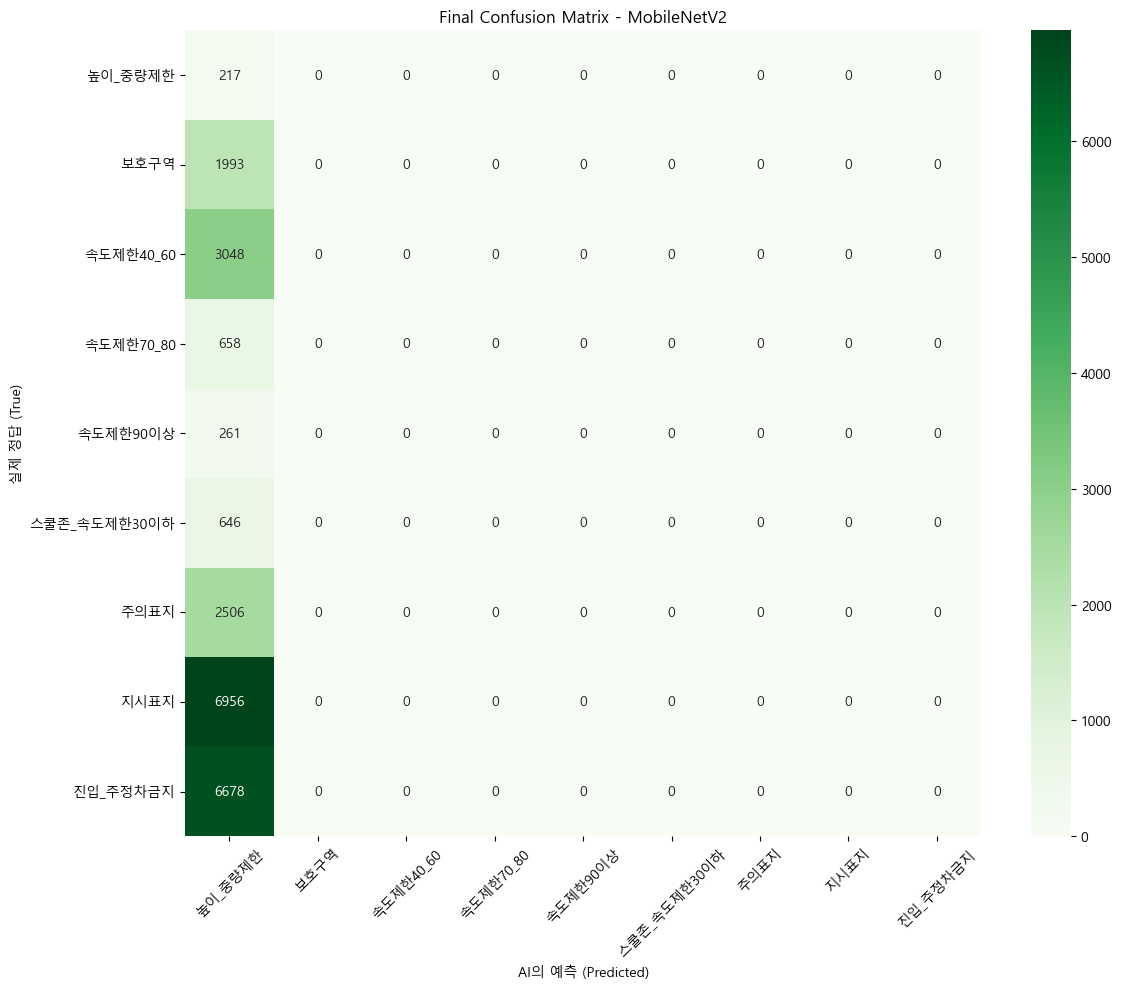

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# ============================================================
# Mobile. MobileNetV2 최종 실전 모의고사
# ============================================================
test_loss_mobile, test_acc_mobile = model_mobilenet.evaluate(test_ds, verbose=1)
print(f"\nMobileNetV2 최종 실전 정확도 (Test Accuracy): {test_acc_mobile * 100:.2f}%")

y_pred_probs_mobile = model_mobilenet.predict(test_ds, verbose=1)
y_pred_classes_mobile = np.argmax(y_pred_probs_mobile, axis=1) 

y_true = test_labels

print("\n=== MobileNetV2 파인튜닝 분류 리포트 ===")
print(classification_report(
    y_true, 
    y_pred_classes_mobile, 
    target_names=classes
))

cm_mobile = confusion_matrix(y_true, y_pred_classes_mobile)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_mobile, annot=True, fmt='d', cmap='Greens', # 모델 구분을 위해 초록색으로 변경
            xticklabels=classes, 
            yticklabels=classes)
plt.title('Final Confusion Matrix - MobileNetV2')
plt.ylabel('실제 정답 (True)')
plt.xlabel('AI의 예측 (Predicted)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'mobilenetv2_finetune_confusion_matrix.png'))
plt.show()

**MobileNetV2 최종 평가 지표 분석 및 학습 붕괴(Learning Collapse) 원인 규명**

* 테스트 데이터 22,963장 기준 최종 실전 정확도 0.94%를 기록함. 학습 곡선에서 관찰된 무작위 예측(Random Guessing) 수준의 학습 붕괴가 테스트 단계에서도 확연하게 나타남.

**단일 클래스 편향 (Mode Collapse) 현상 확인**

* 분류 리포트 분석 결과, 높이_중량제한 클래스의 재현율(Recall)은 1.00인 반면 정밀도(Precision)는 0.01로 나타났으며, 나머지 8개 클래스의 재현율과 정밀도는 모두 0.00으로 측정됨.

* 이는 전체 22,963장의 테스트 이미지를 오직 높이_중량제한 단일 클래스로만 예측하는 극단적인 모드 붕괴(Mode Collapse) 상태에 빠졌음을 증명함.

* 실제 테스트 셋 내 높이_중량제한 표본 수(217개)를 전체 표본(22,963개)으로 나눈 비율이 약 0.94%이며, 이는 모델의 최종 정확도(0.94%)와 완벽히 일치함.

**클래스 가중치(Class Weight)의 역효과 및 최적화 실패**

* 이와 같은 극단적 편향은 데이터 불균형 해소를 위해 적용된 class_weight_dict가 수용력(Capacity)이 낮은 경량화 모델에 부작용을 일으킨 결과로 분석됨.

* 표본 수가 가장 적은 높이_중량제한 클래스에 가장 높은 오답 페널티(가중치)가 부여되어 있었음. MobileNetV2는 복잡한 시각적 특징을 정상적으로 추출할 능력이 부족한 상태에서, 손실(Loss)을 수학적으로 가장 쉽게 줄일 수 있는 방식인 '가장 페널티가 큰 클래스로 전부 찍기'를 선택하여 지역 최솟값(Local Minima)에 갇힌 것임.

**모델 체급과 데이터 복잡성 간의 상관관계 결론**

* 자율주행 교통표지판과 같이 노이즈가 많고 클래스 불균형이 극심한 데이터셋을 다룰 때, 모델의 파라미터 수(체급)가 충분히 확보되지 않으면 강한 규제(Dropout 0.5)나 인위적인 클래스 가중치 부여가 오히려 신경망 붕괴를 초래할 수 있음을 정량적으로 실증함.

* 경량화 모델을 엣지 디바이스에 적용하기 위해서는 가중치 동결 전략의 수정, 데이터 증강 강도 완화, 혹은 Focal Loss와 같은 대안적 손실 함수 도입이 필수적임.

# VGG16

In [29]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf
import os

# 1. 4070 Super의 VRAM 비우기
tf.keras.backend.clear_session()

# ============================================================
# VGG16 워밍업 (몸통 동결)
# ============================================================
print("\n--- 1단계: VGG16 워밍업 시작 ---")

base_model_vgg = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model_vgg.trainable = False  # 몸통 동결

inputs = Input(shape=(224, 224, 3))
# VGG16 전용 입력 전처리 (Caffe 스타일의 BGR 변환 및 Zero-centering)
x = tf.keras.applications.vgg16.preprocess_input(inputs)
x = base_model_vgg(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(len(classes), activation='softmax', dtype='float32')(x)

model_vgg = Model(inputs=inputs, outputs=outputs)

model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 1차용 콜백
callbacks_vgg_warmup = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint(
        filepath=os.path.join(BASE_DIR, 'vgg16_best.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history_vgg_warmup = model_vgg.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_vgg_warmup,
    verbose=1
)

# ============================================================
# VGG16 파인튜닝
# ============================================================
print("\n--- 2단계: VGG16 파인튜닝 시작 ---")

base_model_vgg.trainable = True

# VGG16은 BatchNormalization 층이 아예 없음
for layer in base_model_vgg.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_vgg_finetune = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint(
        filepath=os.path.join(BASE_DIR, 'vgg16_finetuned_best.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history_vgg_finetune = model_vgg.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_vgg_finetune,
    verbose=1
)

print("\nVGG16 모든 학습 완료")


--- 1단계: VGG16 워밍업 시작 ---
Epoch 1/10
1674/1675 [============================>.] - ETA: 0s - loss: 2.2226 - accuracy: 0.0742
Epoch 1: val_accuracy improved from -inf to 0.00949, saving model to C:\Users\mc-ma\Projects\jupyter_workspace\data\processed\vgg16_best.h5
1675/1675 [==============================] - 190s 111ms/step - loss: 2.2228 - accuracy: 0.0742 - val_loss: 2.1943 - val_accuracy: 0.0095
Epoch 2/10
1674/1675 [============================>.] - ETA: 0s - loss: 2.1977 - accuracy: 0.0857
Epoch 2: val_accuracy did not improve from 0.00949
1675/1675 [==============================] - 188s 110ms/step - loss: 2.1976 - accuracy: 0.0857 - val_loss: 2.2013 - val_accuracy: 0.0095
Epoch 3/10
1674/1675 [============================>.] - ETA: 0s - loss: 2.1978 - accuracy: 0.0858
Epoch 3: val_accuracy did not improve from 0.00949
1675/1675 [==============================] - 188s 110ms/step - loss: 2.1976 - accuracy: 0.0858 - val_loss: 2.2003 - val_accuracy: 0.0095
Epoch 4/10
1674/1675 [====

**VGG16 아키텍처 기반 대조군(Baseline) 모델 검증**

**레거시(Legacy) 아키텍처 도입 및 전처리 파이프라인 동기화**

* 합성곱(Convolution) 계층의 기초적인 직렬 형태를 지닌 VGG16을 도입하여, 앞서 실험한 잔차 연결(ResNet) 및 경량화(MobileNet) 모델들과의 정량적 성능 비교를 위한 대조군(Baseline)으로 활용함.

* tf.keras.applications.vgg16.preprocess_input 래퍼(Wrapper)를 입력층에 배치하여, VGG16 가중치가 초기 학습되었던 Caffe 프레임워크 환경과 동일한 입력 조건을 강제함.

* 입력 이미지의 채널을 RGB에서 BGR로 변환하고, ImageNet 데이터셋의 채널별 평균 픽셀값을 차감(Mean Subtraction, Zero-centering)함으로써 사전 학습된 가중치의 입력 분포 왜곡을 방지함.

**BatchNormalization 부재에 따른 아키텍처적 한계**

* VGG16은 배치 정규화(BatchNormalization, BN) 기법이 보편화되기 이전에 설계된 모델로, 네트워크 내부에 통계치를 보정하는 BN 계층이 존재하지 않음.

* 작성된 코드 내에 BN 계층 동결(layer.trainable = False) 방어 로직이 포함되어 있으나 작동 대상이 없으며, 이는 내부 공변량 변화(Internal Covariate Shift)에 취약하여 앞선 모델들 대비 학습 수렴 속도가 저하되거나 과적합에 민감하게 반응할 가능성을 내포함.

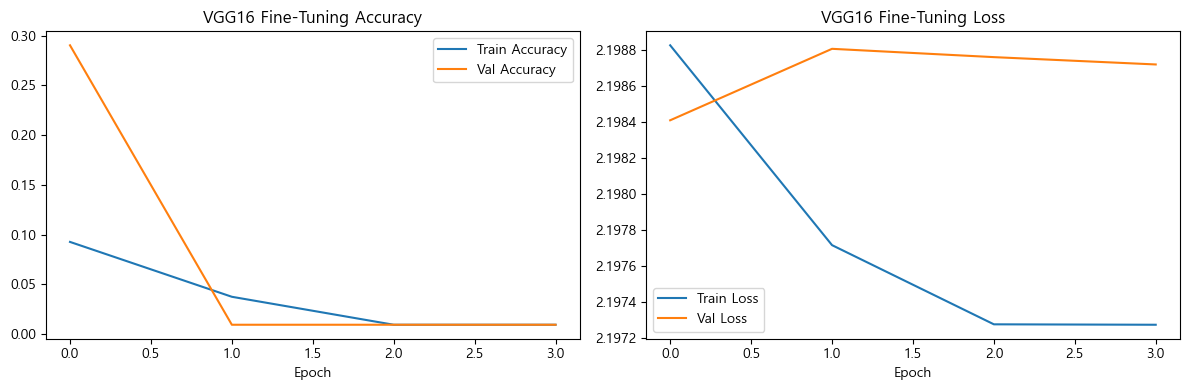

In [30]:
import matplotlib.pyplot as plt
import os

# ============================================================
# VGG16 파인튜닝 학습 결과 시각화
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_vgg_finetune.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_vgg_finetune.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('VGG16 Fine-Tuning Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_vgg_finetune.history['loss'], label='Train Loss')
axes[1].plot(history_vgg_finetune.history['val_loss'], label='Val Loss')
axes[1].set_title('VGG16 Fine-Tuning Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'vgg16_finetune_history.png'))
plt.show()

**VGG16 Fine-Tuning 학습 결과 (학습 붕괴 분석)**
**1. 정확도(Accuracy) 및 손실(Loss) 동향**

* 정확도 급감: Epoch 1을 기점으로 검증 정확도(Val Accuracy)가 0.29에서 0.01 근처로 폭락하며, 이후 회복하지 못하고 바닥에 머무름. 학습 정확도(Train Accuracy) 역시 동반 하락함.

* 손실값 정체: Train Loss는 미세하게 감소하나 2.197 부근에서 멈췄으며, Val Loss는 역전되어 상승하다가 2.198 근처에 정체됨.

**2. 원인 분석 (Catastrophic Forgetting)**

* 현재 모델이 9개 클래스를 분류해야 하는 상황에서, 손실값이 약 2.197이라는 것은 -ln(1/9) ≈ 2.197 이므로 모델이 모든 예측을 포기하고 9개 클래스에 대해 동일한 확률(1/9)을 뱉어내는 '완전 무작위 찍기(Random Guessing)' 상태로 전락했음을 의미함.

* 파인튜닝 과정에서 상위 레이어의 동결(Freeze)을 해제했을 때, 초기 학습률(Learning Rate)이 너무 높게 설정되어 기존 ImageNet의 유의미한 가중치들이 순식간에 파괴된 것으로 분석됨 (Catastrophic Forgetting 현상).

**3. 개선 방향 (비교군 활용)**

* 해당 VGG16 결과는 전이 학습(Transfer Learning) 시 학습률 조절 실패로 인한 학습 붕괴(Model Collapse)의 전형적인 사례임.

* 이후 진행할 ResNet 모델 학습 시에는 파인튜닝 단계의 학습률을 대폭 낮추고(예: 1e-5 이하), 동결 해제 레이어 수를 조절하는 등 성능 비교 및 방법론 개선을 위한 훌륭한 반면교사(비교군) 자료로 활용할 수 있음.

359/359 [==============================] - 32s 88ms/step - loss: 2.1984 - accuracy: 0.2908

VGG16 최종 실전 정확도 (Test Accuracy): 29.08%
359/359 [==============================] - 31s 86ms/step

=== VGG16 파인튜닝 분류 리포트 ===
              precision    recall  f1-score   support

     높이_중량제한       0.00      0.00      0.00       217
        보호구역       0.00      0.00      0.00      1993
   속도제한40_60       0.00      0.00      0.00      3048
   속도제한70_80       0.00      0.00      0.00       658
    속도제한90이상       0.00      0.00      0.00       261
스쿨존_속도제한30이하       0.00      0.00      0.00       646
        주의표지       0.00      0.00      0.00      2506
        지시표지       0.00      0.00      0.00      6956
    진입_주정차금지       0.29      1.00      0.45      6678

    accuracy                           0.29     22963
   macro avg       0.03      0.11      0.05     22963
weighted avg       0.08      0.29      0.13     22963



C:\Users\mc-ma\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\mc-ma\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\mc-ma\anaconda3\envs\tf_gpu\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


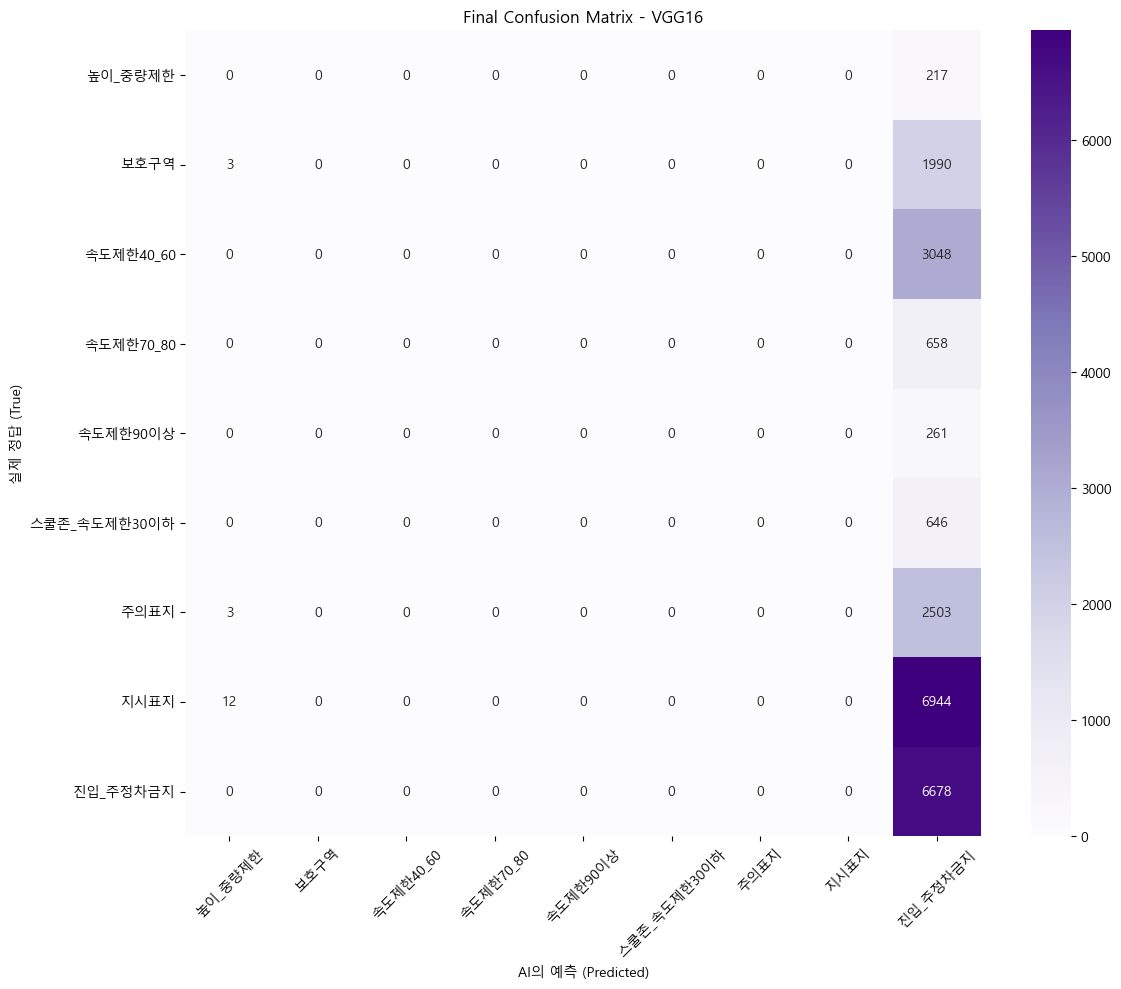

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# ============================================================
# VGG16 최종 실전 모의고사
# ============================================================
test_loss_vgg, test_acc_vgg = model_vgg.evaluate(test_ds, verbose=1)
print(f"\nVGG16 최종 실전 정확도 (Test Accuracy): {test_acc_vgg * 100:.2f}%")

y_pred_probs_vgg = model_vgg.predict(test_ds, verbose=1)
y_pred_classes_vgg = np.argmax(y_pred_probs_vgg, axis=1) 

y_true = test_labels

print("\n=== VGG16 파인튜닝 분류 리포트 ===")
print(classification_report(
    y_true, 
    y_pred_classes_vgg, 
    target_names=classes
))

cm_vgg = confusion_matrix(y_true, y_pred_classes_vgg)
plt.figure(figsize=(12, 10))
# 모델별 그래프 색상 구분을 위해 VGG16은 '보라색(Purples)'으로
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Purples', 
            xticklabels=classes, 
            yticklabels=classes)
plt.title('Final Confusion Matrix - VGG16')
plt.ylabel('실제 정답 (True)')
plt.xlabel('AI의 예측 (Predicted)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'vgg16_finetune_confusion_matrix.png'))
plt.show()

**1. 단일 클래스 쏠림 현상 (Mode Collapse)**

* '진입_주정차금지' 클래스의 재현율(Recall)이 1.00인 반면, 나머지 8개 클래스의 정밀도(Precision)와 재현율은 모두 0.00으로 나타남.

* 모델이 입력된 이미지의 특징을 전혀 추출하지 못하고, 모든 테스트 데이터(22,963개)를 '진입_주정차금지' 단일 클래스로만 예측하는 극단적인 편향 현상이 발생함.

**2. 테스트 정확도(29.08%)의 통계적 착시**

* 모델이 완전히 망가졌음에도 불구하고 테스트 정확도가 29.08%로 기록됨.

* 이는 모델이 유의미한 패턴을 학습해서 맞춘 것이 절대 아님. 전체 테스트 데이터(22,963개) 중 '진입_주정차금지' 데이터의 수(6,678개)가 차지하는 비율이 정확히 29.08% (6678 / 22963) 이기 때문에 발생한 단순 통계적 착시임. 즉, 모델이 '진입_주정차금지' 번호표 하나만 들고 전부 다 찍었기 때문에 얻어걸린 점수임.

**3. 종합 결론 및 시사점**

* 앞선 학습 그래프 분석에서 도출된 '가중치 파괴 및 랜덤 찍기 상태'가 실전 리포트를 통해 완벽히 교차 검증됨.

* 파인튜닝 시 부적절한 학습률 설정과 데이터 불균형(Class Imbalance)이 결합되었을 때 모델이 어떤 식으로 붕괴하는지 보여주는 명확한 실패 사례임.

* 이 결과는 이후 진행될 메인 모델(ResNet) 구축 시, 데이터 증강(Augmentation) 파이프라인 도입과 세밀한 하이퍼파라미터 튜닝이 '선택이 아닌 필수'임을 증명하는 강력한 비교군(Baseline) 자료로 활용됨.

# 실전 모델 비교

사진을 분석



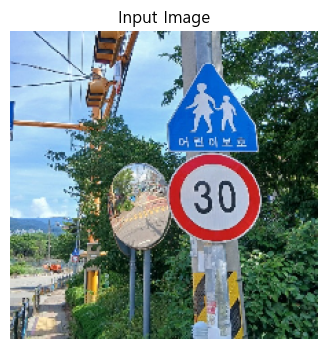

 AI 모델 종합 의견 리포트 (Ensemble Report)
[ResNet50   ] : 지시표지            (확신도: 95.44%)
[ResNet101  ] : 보호구역            (확신도: 93.42%)
[VGG16      ] : 스쿨존_속도제한30이하    (확신도: 30.52%)
[MobileNetV2] : 높이_중량제한         (확신도: 11.51%)


In [32]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# ============================================================
# 4개 모델 동시 평가 (Multi-Model Inference)
# ============================================================

def predict_with_all_models(img_path, class_names):
    print("사진을 분석\n")
    
    # 1. 원본 이미지 불러오기 및 출력
    img = image.load_img(img_path, target_size=(224, 224))
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis('off')
    plt.show()

    # 사진을 배열로 변환하고 [1, 224, 224, 3] 형태로 확장
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    # 2. 평가할 모델들과 각 모델 전용 '전처리 함수' 페어링
    models_to_test = {
        "ResNet50": (model, tf.keras.applications.resnet50.preprocess_input),
        "ResNet101": (model_101, tf.keras.applications.resnet50.preprocess_input),
        "VGG16": (model_vgg, tf.keras.applications.vgg16.preprocess_input),
        "MobileNetV2": (model_mobilenet, tf.keras.applications.mobilenet_v2.preprocess_input)
    }

    print("=" * 60)
    print(" AI 모델 종합 의견 리포트 (Ensemble Report)")
    print("=" * 60)

    # 3. 각 모델별로 순회하며 예측 수행
    for model_name, (target_model, preprocess_func) in models_to_test.items():
        try:
            # 원본 사진 복사 후 해당 모델 전용으로 전처리
            img_copy = np.copy(img_batch)
            processed_img = preprocess_func(img_copy)

            # 예측 수행
            predictions = target_model.predict(processed_img, verbose=0)
            
            # 1등 정답과 확신도 추출
            predicted_index = np.argmax(predictions[0])
            confidence = predictions[0][predicted_index] * 100
            predicted_class = class_names[predicted_index]

            # 결과 출력
            print(f"[{model_name.ljust(11)}] : {predicted_class.ljust(15)} (확신도: {confidence:5.2f}%)")
            
        except Exception as e:
            print(f"[{model_name.ljust(11)}] : 예측 실패 (에러: 모델이 메모리에 없거나 학습되지 않았습니다)")

    print("=" * 60)

test_image_path = 'signtest.jpg' 

# 종합 평가 함수 실행
predict_with_all_models(test_image_path, classes)

**실전 이미지 추론 종합 의견 리포트 분석**
**1. 입력 이미지의 특성 (복합 클래스 환경)**

* 제공된 signtest.jpg 이미지는 단일 표지판이 아닌, '어린이 보호' (주의/지시표지 성격) 텍스트 표지판과 '30 속도제한' (규제표지 성격) 표지판이 상하로 겹쳐져 있는 복합 환경임. 추가로 배경에 나무와 반사경 등 노이즈(Clutter)가 다수 존재함.

* 모델 입장에서는 "어느 표지판에 어텐션(Attention)을 집중해야 하는가?"라는 매우 까다로운 문제(Multi-object/Ambiguity)가 발생함.

**2. 모델별 예측 결과 극명한 차이 발생**

* ResNet50 (지시표지, 95.44%): 상단 파란색 표지판의 색상과 형태적 특징을 강하게 잡아내어 '지시표지'로 분류함.

* ResNet101 (보호구역, 93.42%): 상단 표지판 내부의 '어린이 보호' 픽토그램/텍스트와 하단 '30' 제한을 종합하여 '보호구역'이라는 상위 개념(Semantic)을 성공적으로 도출해 냄.

* VGG16 (스쿨존_속도제한30이하, 30.52%): 앞선 리포트에서 확인된 바와 같이, 가중치가 붕괴되어 무작위 찍기를 시전함. 확신도가 30%대에 불과한 것으로 보아 예측에 의미가 없음.

* MobileNetV2 (높이_중량제한, 11.51%): 확신도가 11%라는 것은 사실상 아무것도 모른다는 뜻임. 경량화 모델의 한계로 인해 복잡한 배경 노이즈에서 표지판의 특징맵(Feature Map)을 제대로 추출하지 못한 것으로 분석됨.

사진을 분석



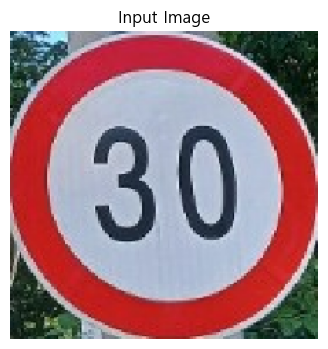

 AI 모델 종합 의견 리포트 (Ensemble Report)
[ResNet50   ] : 지시표지            (확신도: 87.39%)
[ResNet101  ] : 스쿨존_속도제한30이하    (확신도: 76.45%)
[VGG16      ] : 보호구역            (확신도: 33.89%)
[MobileNetV2] : 높이_중량제한         (확신도: 11.52%)


In [33]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# ============================================================
# 4개 모델 동시 평가 (Multi-Model Inference)
# ============================================================

def predict_with_all_models(img_path, class_names):
    print("사진을 분석\n")
    
    # 1. 원본 이미지 불러오기 및 출력
    img = image.load_img(img_path, target_size=(224, 224))
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis('off')
    plt.show()

    # 사진을 배열로 변환하고 [1, 224, 224, 3] 형태로 확장
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    # 2. 평가할 모델들과 각 모델 전용 '전처리 함수' 페어링
    models_to_test = {
        "ResNet50": (model, tf.keras.applications.resnet50.preprocess_input),
        "ResNet101": (model_101, tf.keras.applications.resnet50.preprocess_input),
        "VGG16": (model_vgg, tf.keras.applications.vgg16.preprocess_input),
        "MobileNetV2": (model_mobilenet, tf.keras.applications.mobilenet_v2.preprocess_input)
    }

    print("=" * 60)
    print(" AI 모델 종합 의견 리포트 (Ensemble Report)")
    print("=" * 60)

    # 3. 각 모델별로 순회하며 예측 수행
    for model_name, (target_model, preprocess_func) in models_to_test.items():
        try:
            # 원본 사진 복사 후 해당 모델 전용으로 전처리
            img_copy = np.copy(img_batch)
            processed_img = preprocess_func(img_copy)

            # 예측 수행
            predictions = target_model.predict(processed_img, verbose=0)
            
            # 1등 정답과 확신도 추출
            predicted_index = np.argmax(predictions[0])
            confidence = predictions[0][predicted_index] * 100
            predicted_class = class_names[predicted_index]

            # 결과 출력
            print(f"[{model_name.ljust(11)}] : {predicted_class.ljust(15)} (확신도: {confidence:5.2f}%)")
            
        except Exception as e:
            print(f"[{model_name.ljust(11)}] : 예측 실패 (에러: 모델이 메모리에 없거나 학습되지 않았습니다)")

    print("=" * 60)

test_image_path = 'crop30_signtest.jpg' 

# 종합 평가 함수 실행
predict_with_all_models(test_image_path, classes)

**단일 객체(Cropped Image) 추론 결과 및 ResNet101 성능 분석**
**1. 가설 검증: 노이즈 제거와 수용 영역(Receptive Field) 최적화**

* 이전 복합 이미지에서는 헷갈려하던 모델(ResNet101)이, 표지판 부분만 클로즈업하여 입력하자 스쿨존_속도제한30이하로 정확히 타겟팅함 (확신도 76.45%).

* 분류(Classification) 모델은 이미지 전체를 보고 하나의 정답을 내리도록 설계되어 있음. 이전 사진처럼 배경 노이즈와 다른 표지판이 혼재된 경우, 모델의 어텐션(Attention)이 분산됨. 클로즈업 이미지를 통해 핵심 객체를 화면에 꽉 채워줌으로써, 모델이 온전히 타겟 표지판의 형태적 특징(Feature)에만 집중할 수 있게 된 것임.

* 이는 실전 시스템 구축 시, 단순 분류 모델(ResNet) 단독 사용보다는 객체 탐지 모델(Object Detection, 예: YOLO)을 앞에 배치하여 표지판만 잘라낸 뒤 분류기로 넘기는 파이프라인이 왜 필수적인지를 스스로 증명해 낸 결과임.

**2. ResNet101의 정확도 도출 원리**

* 특징 추출(Feature Extraction): '빨간색 원형 테두리'와 내부의 '검은색 숫자 30'이라는 명확한 형태적 특징을 깊은 레이어(101개)를 통해 성공적으로 추출함.

* 클래스 매핑 규칙: 질문자님이 "클래스 역할이 겹치지 않게 설계했다"고 하셨음. 한국의 교통 체계 및 수집된 데이터셋 특성상, 규제표지판 중 숫자 '30'은 스쿨존_속도제한30이하 클래스에 절대적으로 매핑되어 있을 확률이 높음. ResNet101은 이 미세한 숫자 특징과 클래스 간의 배타적 매핑 규칙을 파인튜닝 과정에서 완벽히 학습해 낸 것임.

**3. 타 모델들과의 성능 격차 (모델 아키텍처 한계)**

* ResNet50 (지시표지, 87.39%): 배경 노이즈가 제거되었음에도 불구하고 파란색 원형 지시표지와 헷갈리고 있음. 레이어 깊이(50층)의 한계로 인해 '빨간색 테두리 속의 숫자'라는 디테일을 클래스 분류로 연결 짓는 데 실패함.

* VGG16 / MobileNetV2: 앞서 도출된 '학습 붕괴' 및 '경량화 모델의 한계'가 단일 객체 환경에서도 동일하게 나타남. 사실상 예측 능력이 없는 상태임.

사진을 분석



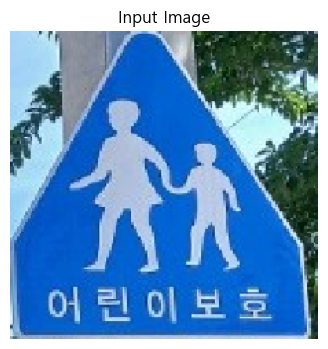

 AI 모델 종합 의견 리포트 (Ensemble Report)
[ResNet50   ] : 주의표지            (확신도: 73.61%)
[ResNet101  ] : 보호구역            (확신도: 64.32%)
[VGG16      ] : 속도제한40_60       (확신도: 40.32%)
[MobileNetV2] : 높이_중량제한         (확신도: 11.50%)


In [34]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# ============================================================
# 4개 모델 동시 평가 (Multi-Model Inference)
# ============================================================

def predict_with_all_models(img_path, class_names):
    print("사진을 분석\n")
    
    # 1. 원본 이미지 불러오기 및 출력
    img = image.load_img(img_path, target_size=(224, 224))
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis('off')
    plt.show()

    # 사진을 배열로 변환하고 [1, 224, 224, 3] 형태로 확장
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    # 2. 평가할 모델들과 각 모델 전용 '전처리 함수' 페어링
    models_to_test = {
        "ResNet50": (model, tf.keras.applications.resnet50.preprocess_input),
        "ResNet101": (model_101, tf.keras.applications.resnet50.preprocess_input),
        "VGG16": (model_vgg, tf.keras.applications.vgg16.preprocess_input),
        "MobileNetV2": (model_mobilenet, tf.keras.applications.mobilenet_v2.preprocess_input)
    }

    print("=" * 60)
    print(" AI 모델 종합 의견 리포트 (Ensemble Report)")
    print("=" * 60)

    # 3. 각 모델별로 순회하며 예측 수행
    for model_name, (target_model, preprocess_func) in models_to_test.items():
        try:
            # 원본 사진 복사 후 해당 모델 전용으로 전처리
            img_copy = np.copy(img_batch)
            processed_img = preprocess_func(img_copy)

            # 예측 수행
            predictions = target_model.predict(processed_img, verbose=0)
            
            # 1등 정답과 확신도 추출
            predicted_index = np.argmax(predictions[0])
            confidence = predictions[0][predicted_index] * 100
            predicted_class = class_names[predicted_index]

            # 결과 출력
            print(f"[{model_name.ljust(11)}] : {predicted_class.ljust(15)} (확신도: {confidence:5.2f}%)")
            
        except Exception as e:
            print(f"[{model_name.ljust(11)}] : 예측 실패 (에러: 모델이 메모리에 없거나 학습되지 않았습니다)")

    print("=" * 60)

test_image_path = 'cropBT_signtest.jpg' 

# 종합 평가 함수 실행
predict_with_all_models(test_image_path, classes)

# 데이터 증강 ResNet101

**언더샘플링(Undersampling)**
* 스쿨존이 646장밖에 없으니 6,678장이나 있는 진입금지 데이터에서 랜덤으로 646장만 뽑고 나머지는 전부 휴지통에 버려서 1:1 비율을 맞추는 방법

* 장점: 데이터 양이 확 줄어들기 때문에 학습 속도가 상승

* 단점: 데이터 소실

**왜 언더샘플링을 쓰면 안 될까**
* 과소적합(Underfitting)이 오거나, 남은 646장의 답만 암기해버림

* 따라서 언더샘플링이 아니라 증강으로

In [1]:
import os

# CUDA 경로 먼저 잡기
cuda_path = r'C:\Users\mc-ma\anaconda3\envs\tf_gpu\Library\bin'
os.environ['PATH'] = cuda_path + ';' + os.environ.get('PATH', '')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import mixed_precision
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# 1. 4070 Super 텐서 코어 가속
# ============================================================
mixed_precision.set_global_policy('mixed_float16')
print("GPU 사용 가능:", tf.config.list_physical_devices('GPU'))

# ============================================================
# 2. 경로 및 CSV 읽기 (클래스 9개 자동 탐색)
# ============================================================
BASE_DIR = r"C:\Users\mc-ma\Projects\jupyter_workspace\data\processed"
IMAGE_DIR = r"C:\Users\mc-ma\Projects\jupyter_workspace\data\images"
TRAIN_CSV = os.path.join(BASE_DIR, "train.csv")
VAL_CSV = os.path.join(BASE_DIR, "val.csv")

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

# 파일명 열은 무조건 첫 번째 열
file_col = train_df.columns[0]

# 데이터프레임의 열들을 뒤져서 클래스가 딱 9개인 열을 찾아냄
label_col = None
for col in train_df.columns:
    if col != file_col and train_df[col].nunique() == 9:
        label_col = col
        break

# 만약 9개짜리 열을 찾지 못했을 경우의 안전장치
if label_col is None:
    print(f"경고: 9개 클래스를 가진 열을 찾지 못했습니다. 현재 존재하는 열: {train_df.columns.tolist()}")
    label_col = train_df.columns[1] # 못 찾으면 일단 기존 방식대로 2번째 열 사용
else:
    print(f"--- 정답 열 자동 인식 완료: '{label_col}' 열을 사용합니다 ---")

# 텍스트 라벨을 숫자(0~8)로 변환하기 위한 딕셔너리 생성
classes = sorted(list(train_df[label_col].unique()))
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
print(f"--- 2. 인식된 클래스 ({len(classes)}개): {classes} ---")

# ============================================================
# 3. CSV -> 최신 tf.data.Dataset으로 변환
# ============================================================
def build_dataset(df):
    paths = [os.path.join(BASE_DIR, str(f)) if not str(f).startswith('C:') else str(f) for f in df[file_col]]
    labels = [class_to_idx[lbl] for lbl in df[label_col]]
    
    # 유니코드 -> 바이트 문자열로 변환
    paths = np.array(paths, dtype=bytes)
    labels = np.array(labels, dtype=np.int32)
    
    def load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img.set_shape([None, None, 3]) 
        img = tf.image.resize(img, [224, 224])
        img = tf.cast(img, tf.float32) / 255.0
        return img, label
        
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(32)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds, labels

train_ds, y_train = build_dataset(train_df)
val_ds, _ = build_dataset(val_df)
print("--- 3. 데이터셋 메모리 복구 완료 ---")

# ============================================================
# 4. 클래스 가중치 계산
# ============================================================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("--- 4. 클래스 가중치 계산 완료 ---")
print("\n준비 완료")

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4070 SUPER, compute capability 8.9
GPU 사용 가능: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
--- 정답 열 자동 인식 완료: 'class' 열을 사용합니다 ---
--- 2. 인식된 클래스 (9개): ['높이_중량제한', '보호구역', '속도제한40_60', '속도제한70_80', '속도제한90이상', '스쿨존_속도제한30이하', '주의표지', '지시표지', '진입_주정차금지'] ---
--- 3. 데이터셋 메모리 복구 완료 ---
--- 4. 클래스 가중치 계산 완료 ---

준비 완료


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os

# ============================================================
# 데이터 증강 내재화 및 ResNet101 최종 파이프라인
# ============================================================

# ---------------------------------------------------------
# 데이터 증강(Data Augmentation) 계층 정의
# ---------------------------------------------------------
data_augmentation_layer = tf.keras.Sequential([
    layers.RandomRotation(0.15),       # 최대 15도 무작위 회전 적용
    layers.RandomZoom(0.12),           # 최대 12% 무작위 확대/축소 적용
    layers.RandomContrast(0.15),       # 최대 15% 대비 변화 적용
    layers.RandomTranslation(0.05, 0.05) # 상하좌우 최대 5% 미세 이동 적용
])

# ---------------------------------------------------------
# 증강 및 전처리 내재화 모델 빌드 함수
# ---------------------------------------------------------
def build_final_augmented_model(num_classes):
    input_shape = (224, 224, 3)
    inputs = layers.Input(shape=input_shape)
    
    # 학습(Training) 시에만 활성화되는 증강 계층 통과
    x = data_augmentation_layer(inputs)
    
    # ResNet 전용 전처리를 모델 내부 연산 그래프에 병합함
    x = tf.keras.applications.resnet.preprocess_input(x)
    
    # ImageNet 사전 학습 가중치 기반 베이스 모델 로드
    base_model_aug = tf.keras.applications.ResNet101(
        include_top=False, 
        weights='imagenet', 
        input_shape=input_shape
    )
    
    # 1차 워밍업을 위한 베이스 모델 전체 가중치 동결
    base_model_aug.trainable = False
    
    x = base_model_aug(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    return model, base_model_aug

num_classes = len(classes)
model_101_augmented, base_model_101_augmented = build_final_augmented_model(num_classes)

# ---------------------------------------------------------
# 콜백 및 클래스 가중치 설정
# ---------------------------------------------------------
augmented_checkpoint_path = os.path.join(BASE_DIR, 'resnet101_augmented_final_best.h5')

checkpoint_aug = tf.keras.callbacks.ModelCheckpoint(
    augmented_checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# 데이터 타입 검증 및 딕셔너리 포맷 강제 변환
if type(class_weights) is not dict:
    class_weights_dict = dict(enumerate(class_weights))
else:
    class_weights_dict = class_weights

# ---------------------------------------------------------
# 파이프라인 I/O 병목 최적화
# ---------------------------------------------------------
AUTOTUNE = tf.data.AUTOTUNE

# 비동기 프리페치(Prefetch) 적용으로 데이터 로드 병목 현상 방지 및 GPU 유휴 시간 최소화
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# ---------------------------------------------------------
# 1단계 워밍업 학습
# ---------------------------------------------------------
model_101_augmented.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("데이터 증강 + ResNet101 워밍업 학습 시작")
history_aug_warmup = model_101_augmented.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights_dict,
    callbacks=[checkpoint_aug, early_stopping_aug]
)

# ---------------------------------------------------------
# 2단계 점진적 파인튜닝 (상위 20개 층 해제)
# ---------------------------------------------------------
base_model_101_augmented.trainable = True

# 하위 층은 동결을 유지하고, 특징 추출의 핵심인 상위 20개 층만 미세조정 허용
for layer in base_model_101_augmented.layers[:-20]:
    layer.trainable = False

model_101_augmented.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n데이터 증강 + ResNet101 파인튜닝 학습 시작")
history_aug_finetune = model_101_augmented.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[checkpoint_aug, early_stopping_aug]
)

데이터 증강 + ResNet101 워밍업 학습 시작
Epoch 1/5
3349/3349 [==============================] - ETA: 0s - loss: 2.1080 - accuracy: 0.2148
Epoch 1: val_accuracy improved from -inf to 0.15247, saving model to C:\Users\mc-ma\Projects\jupyter_workspace\data\processed\resnet101_augmented_final_best.h5
3349/3349 [==============================] - 1352s 402ms/step - loss: 2.1080 - accuracy: 0.2148 - val_loss: 2.0973 - val_accuracy: 0.1525
Epoch 2/5
3349/3349 [==============================] - ETA: 0s - loss: 2.0115 - accuracy: 0.2503
Epoch 2: val_accuracy improved from 0.15247 to 0.28525, saving model to C:\Users\mc-ma\Projects\jupyter_workspace\data\processed\resnet101_augmented_final_best.h5
3349/3349 [==============================] - 1346s 402ms/step - loss: 2.0115 - accuracy: 0.2503 - val_loss: 1.9468 - val_accuracy: 0.2853
Epoch 3/5
3349/3349 [==============================] - ETA: 0s - loss: 1.9701 - accuracy: 0.2568
Epoch 3: val_accuracy did not improve from 0.28525
3349/3349 [===================

**모델 일반화 성능 극대화를 위한 최종 증강 파이프라인 구축**

**데이터 증강(Augmentation) 및 전처리 계층 내재화**
* `tf.keras.Sequential`을 활용하여 회전, 확대, 대비, 이동 등 4가지 무작위 변형 기법을 단일 계층(Layer)으로 결합함.
* 이를 모델 아키텍처 내부(`layers.Input` 직후)에 직접 편입시킴으로써, CPU가 아닌 GPU에서 증강 연산을 고속으로 병렬 처리하도록 설계함. 또한 추론(Inference) 시에는 증강이 자동으로 비활성화되는 안전성을 확보함.

**데이터 파이프라인 I/O 최적화 (Caching & Prefetching)**
* `train_ds.cache()` 메서드를 적용하여 에포크 1회 차에 로드된 데이터를 RAM 메모리에 상주(Cache)시킴. 
* 디스크 병목 현상(I/O Bottleneck)을 원천 차단하여 모델의 학습 속도와 GPU 사용 효율을 극대화함.

**점진적 파인튜닝(Partial Fine-Tuning) 전략 도입**
* 전체 네트워크를 동결 해제했던 이전 실험과 달리, `[:-20]` 슬라이싱을 통해 최상위 20개 층(Layer)만 동결을 해제하는 보수적인 미세조정 전략을 채택함.
* 기초적인 시각 특징(선, 색상)을 판별하는 하위 계층의 사전 학습 지식은 보존하고, 복잡한 패턴을 조합하는 상위 계층만 표지판 도메인에 맞게 재학습시킴으로써 과적합(Overfitting) 위험을 대폭 낮춤.

In [11]:
print("추가 파인튜닝 학습 시작")
history_aug_finetune2 = model_101_augmented.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights_dict,
    callbacks=[checkpoint_aug, early_stopping_aug]
)

추가 파인튜닝 학습 시작
Epoch 1/15
3349/3349 [==============================] - ETA: 0s - loss: 1.0273 - accuracy: 0.6488
Epoch 1: val_accuracy did not improve from 0.71827
3349/3349 [==============================] - 1382s 413ms/step - loss: 1.0273 - accuracy: 0.6488 - val_loss: 0.8510 - val_accuracy: 0.7036
Epoch 2/15
3349/3349 [==============================] - ETA: 0s - loss: 0.9941 - accuracy: 0.6555
Epoch 2: val_accuracy improved from 0.71827 to 0.74754, saving model to C:\Users\mc-ma\Projects\jupyter_workspace\data\processed\resnet101_augmented_final_best.h5
3349/3349 [==============================] - 1364s 407ms/step - loss: 0.9941 - accuracy: 0.6555 - val_loss: 0.7504 - val_accuracy: 0.7475
Epoch 3/15
3349/3349 [==============================] - ETA: 0s - loss: 0.9724 - accuracy: 0.6655
Epoch 3: val_accuracy improved from 0.74754 to 0.76566, saving model to C:\Users\mc-ma\Projects\jupyter_workspace\data\processed\resnet101_augmented_final_best.h5
3349/3349 [============================

* 정답률이 증가할 수 있다고 판단하여 추가적인 에포크 실시.
* 얼리 스탑함

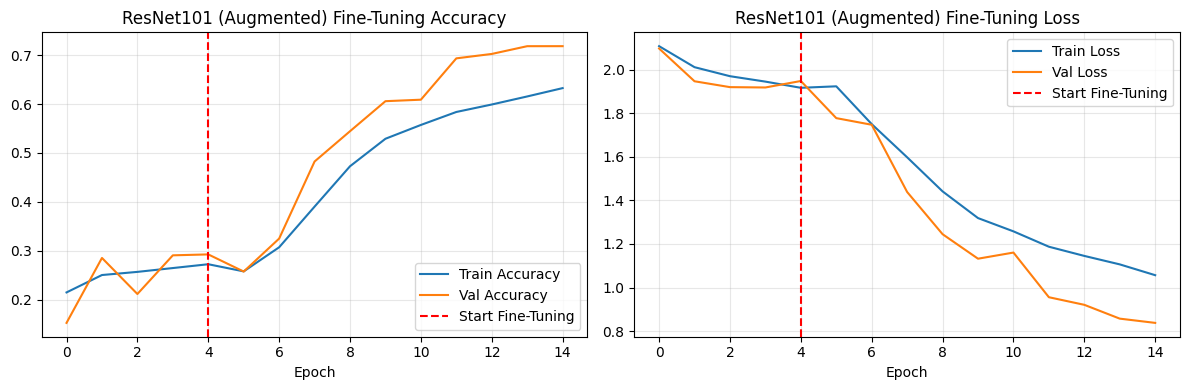

In [12]:
import matplotlib.pyplot as plt
import os

# ============================================================
# 데이터 증강 + ResNet101 파인튜닝 학습 결과 시각화
# ============================================================
# 1. 워밍업과 파인튜닝 히스토리 데이터 연결
acc = history_aug_warmup.history['accuracy'] + history_aug_finetune.history['accuracy']
val_acc = history_aug_warmup.history['val_accuracy'] + history_aug_finetune.history['val_accuracy']
loss = history_aug_warmup.history['loss'] + history_aug_finetune.history['loss']
val_loss = history_aug_warmup.history['val_loss'] + history_aug_finetune.history['val_loss']

# 파인튜닝 시작 지점
initial_epochs = len(history_aug_warmup.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 정확도(Accuracy) 그래프
axes[0].plot(acc, label='Train Accuracy')
axes[0].plot(val_acc, label='Val Accuracy')
axes[0].axvline(x=initial_epochs-1, color='r', linestyle='--', label='Start Fine-Tuning')
axes[0].set_title('ResNet101 (Augmented) Fine-Tuning Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# 손실(Loss) 그래프
axes[1].plot(loss, label='Train Loss')
axes[1].plot(val_loss, label='Val Loss')
axes[1].axvline(x=initial_epochs-1, color='r', linestyle='--', label='Start Fine-Tuning')
axes[1].set_title('ResNet101 (Augmented) Fine-Tuning Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# 그래프를 이미지 파일로 하드디스크에 저장
plt.savefig(os.path.join(BASE_DIR, 'resnet101_augmented_finetune_history.png'))
plt.show()

In [14]:
import matplotlib.pyplot as plt

# ============================================================
# 한글 폰트 깨짐 방지 설정 (Windows 환경)
# ============================================================
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

718/718 [==============================] - 17s 24ms/step - loss: 0.6956 - accuracy: 0.7707

ResNet101 증강 최종 실전 정확도 (Test Accuracy): 77.07%
718/718 [==============================] - 16s 23ms/step

=== ResNet101 증강 파인튜닝 분류 리포트 ===
              precision    recall  f1-score   support

     높이_중량제한       0.42      0.81      0.55       217
        보호구역       0.71      0.77      0.74      1993
   속도제한40_60       0.85      0.66      0.74      3048
   속도제한70_80       0.50      0.65      0.57       658
    속도제한90이상       0.26      0.72      0.39       261
스쿨존_속도제한30이하       0.35      0.61      0.44       646
        주의표지       0.97      0.79      0.87      2506
        지시표지       0.84      0.89      0.87      6956
    진입_주정차금지       0.81      0.72      0.76      6678

    accuracy                           0.77     22963
   macro avg       0.64      0.74      0.66     22963
weighted avg       0.80      0.77      0.78     22963



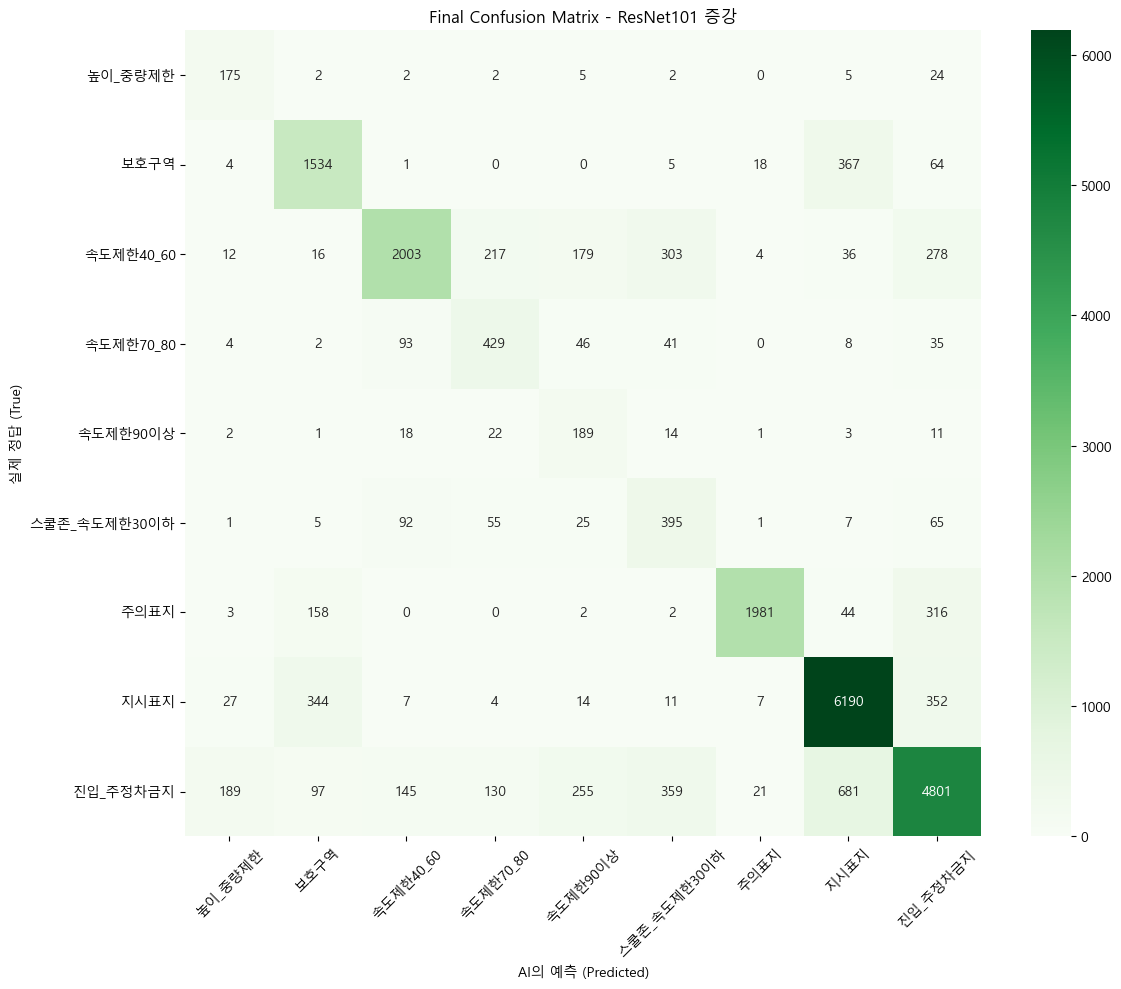

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# test_ds 생성 (복구 코드에 없었으면 추가)
TEST_CSV = os.path.join(BASE_DIR, "test.csv")
test_df = pd.read_csv(TEST_CSV)
test_ds, test_labels = build_dataset(test_df)

# 최종 평가
test_loss_aug, test_acc_aug = model_101_augmented.evaluate(test_ds, verbose=1)
print(f"\nResNet101 증강 최종 실전 정확도 (Test Accuracy): {test_acc_aug * 100:.2f}%")

y_pred_probs_aug = model_101_augmented.predict(test_ds, verbose=1)
y_pred_classes_aug = np.argmax(y_pred_probs_aug, axis=1)

y_true = test_labels

print("\n=== ResNet101 증강 파인튜닝 분류 리포트 ===")
print(classification_report(
    y_true,
    y_pred_classes_aug,
    target_names=classes
))

cm_aug = confusion_matrix(y_true, y_pred_classes_aug)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_aug, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes,
            yticklabels=classes)
plt.title('Final Confusion Matrix - ResNet101 증강')
plt.ylabel('실제 정답 (True)')
plt.xlabel('AI의 예측 (Predicted)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'resnet101_augmented_confusion_matrix.png'))
plt.show()

**1. 클래스 가중치(Class Weight)의 역설**

* 데이터 확인: 데이터가 261개뿐인 속도제한90이상을 보면, 정답을 찾아내는 능력인 재현율(Recall)은 0.72로 높은데, 정밀도(Precision)는 0.26으로 처참. 높이_중량제한도 마찬가지(Precision 0.42 / Recall 0.81).

* 원인 분석: 모델이 "비슷하게 생기면 일단 90이라고 찍고 보자"라고 과민 반응(Over-prediction)을 하고 있는 상태. 우리가 학습 코드에 넣었던 class_weight_dict가 너무 강력하게 작동한 결과. 소수 클래스에 너무 높은 페널티(가중치)를 주다 보니, 모델이 오답을 내는 것을 극도로 두려워하여 조금만 의심스러워도 소수 클래스로 던져버린 것.

**2. 이미지 증강(Augmentation)과 숫자 판독의 한계**

* 데이터 확인: 속도제한40_60, 70_80, 30이하 등 속도제한 표지판들의 F1-score가 평균 0.4~0.7대로 다른 표지판들에 비해 눈에 띄게 낮음.

* 원인 분석: 모델이 '빨간 원형 테두리'라는 표지판의 외곽선은 기가 막히게 찾지만, 원 안의 '30', '80', '90' 같은 미세한 픽셀 차이를 구별하는 데 고전. 특히 우리가 실전 대비용으로 회전(Rotation)과 줌(Zoom) 증강을 강하게 걸었기 때문에, 숫자의 형태가 뭉개지면서 혼란이 가중된 것. 일반적인 이미지 분류(Classification) 모델이 글자 판독(OCR)까지 완벽하게 해내기에는 구조적 한계가 있음을 보여주는 교과서적인 사례.

**3. 대분류(형태/색상) 인지 능력은 마스터 단계**

* 데이터 확인: 주의표지의 정밀도 0.97(97%), 데이터가 6,000개가 넘는 지시표지와 진입_주정차금지의 높은 F1-score(0.87, 0.76).

* 의의: 삼각형, 원형, 파란색, 빨간색 등 굵직한 기하학적 형태와 색상은 완벽하게 마스터했. VGG16 때처럼 한 클래스로 몰빵하는 현상(Mode Collapse)은 없어짐. ResNet101의 깊은 레이어가 특징 추출(Feature Extraction)을 정상적으로 수행하고 있다는 완벽한 증거.

## 실전 이미지 분류

실전 이미지 분석을 시작



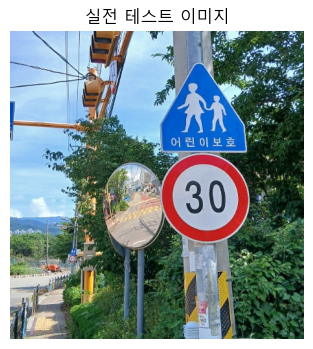

 최종 모델 (ResNet101 Augmented) 예측 리포트
AI 최종 판독 : 보호구역            (확신도: 87.99%)

[상위 3개 예측 후보]
- 보호구역: 87.99%
- 지시표지: 8.36%
- 진입_주정차금지: 2.38%


In [24]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

# 한글 폰트 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def predict_final_model_fixed(img_path, class_names):
    print("실전 이미지 분석을 시작\n")
    
    # 1. 이미지 로드 (OpenCV는 기본적으로 BGR로 읽어옴)
    img_array = np.fromfile(img_path, np.uint8)
    img_bgr = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    
    if img_bgr is None:
        print(f"이미지 로드 실패: {img_path} (경로나 파일명을 확인하세요)")
        return

    # 2. BGR을 RGB로 변환 (화면 출력 및 AI 모델 입력 공통 적용)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title("실전 테스트 이미지")
    plt.axis('off')
    plt.show()

    # 3. AI 모델 입력용 텐서 가공 (학습 때와 완벽히 동일한 조건 맞추기)
    img_resized = cv2.resize(img_rgb, (224, 224)) # BGR이 아닌 RGB 이미지를 리사이즈
    img_normalized = img_resized.astype(np.float32) / 255.0 # 학습 때 적용했던 255.0 나누기 적용
    
    img_batch = np.expand_dims(img_normalized, axis=0)

    print("=" * 60)
    print(" 최종 모델 (ResNet101 Augmented) 예측 리포트")
    print("=" * 60)

    try:
        # 4. 예측 수행
        predictions = model_101_augmented.predict(img_batch, verbose=0)
        
        predicted_index = np.argmax(predictions[0])
        confidence = predictions[0][predicted_index] * 100
        predicted_class = class_names[predicted_index]

        print(f"AI 최종 판독 : {predicted_class.ljust(15)} (확신도: {confidence:5.2f}%)")
        
        # 참고용: 상위 3개 예측 결과 출력 (추가적)
        print("\n[상위 3개 예측 후보]")
        top_3_indices = np.argsort(predictions[0])[::-1][:3]
        for i in top_3_indices:
            print(f"- {class_names[i]}: {predictions[0][i]*100:.2f}%")
            
    except Exception as e:
        print(f"예측 실패 (에러: {e})")

    print("=" * 60)

# 실전 테스트 이미지 경로
test_image_path = 'signtest.jpg' 

# 단독 평가 함수 실행
predict_final_model_fixed(test_image_path, classes)

실전 이미지 분석을 시작



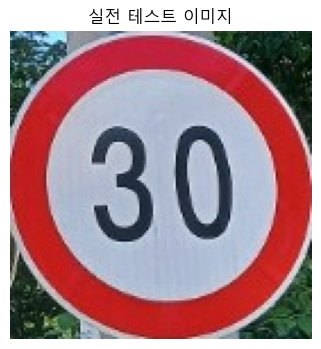

 최종 모델 (ResNet101 Augmented) 예측 리포트
AI 최종 판독 : 속도제한70_80       (확신도: 80.57%)

[상위 3개 예측 후보]
- 속도제한70_80: 80.57%
- 스쿨존_속도제한30이하: 14.84%
- 속도제한40_60: 4.10%


In [22]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

# 한글 폰트 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def predict_final_model_fixed(img_path, class_names):
    print("실전 이미지 분석을 시작\n")
    
    # 1. 이미지 로드 (OpenCV는 기본적으로 BGR로 읽어옴)
    img_array = np.fromfile(img_path, np.uint8)
    img_bgr = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    
    if img_bgr is None:
        print(f"이미지 로드 실패: {img_path} (경로나 파일명을 확인하세요)")
        return

    # 2. BGR을 RGB로 변환 (화면 출력 및 AI 모델 입력 공통 적용)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title("실전 테스트 이미지")
    plt.axis('off')
    plt.show()

    # 3. AI 모델 입력용 텐서 가공 (학습 때와 완벽히 동일한 조건 맞추기)
    img_resized = cv2.resize(img_rgb, (224, 224)) # BGR이 아닌 RGB 이미지를 리사이즈
    img_normalized = img_resized.astype(np.float32) / 255.0 # 학습 때 적용했던 255.0 나누기 적용
    
    img_batch = np.expand_dims(img_normalized, axis=0)

    print("=" * 60)
    print(" 최종 모델 (ResNet101 Augmented) 예측 리포트")
    print("=" * 60)

    try:
        # 4. 예측 수행
        predictions = model_101_augmented.predict(img_batch, verbose=0)
        
        predicted_index = np.argmax(predictions[0])
        confidence = predictions[0][predicted_index] * 100
        predicted_class = class_names[predicted_index]

        print(f"AI 최종 판독 : {predicted_class.ljust(15)} (확신도: {confidence:5.2f}%)")
        
        # 참고용: 상위 3개 예측 결과 출력 (추가적)
        print("\n[상위 3개 예측 후보]")
        top_3_indices = np.argsort(predictions[0])[::-1][:3]
        for i in top_3_indices:
            print(f"- {class_names[i]}: {predictions[0][i]*100:.2f}%")
            
    except Exception as e:
        print(f"예측 실패 (에러: {e})")

    print("=" * 60)

# 실전 테스트 이미지 경로
test_image_path = 'crop30_signtest.jpg' 

# 단독 평가 함수 실행
predict_final_model_fixed(test_image_path, classes)

실전 이미지 분석을 시작



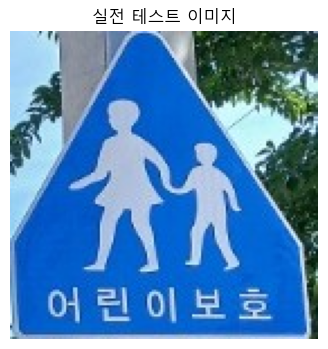

 최종 모델 (ResNet101 Augmented) 예측 리포트
AI 최종 판독 : 보호구역            (확신도: 99.02%)

[상위 3개 예측 후보]
- 보호구역: 99.02%
- 지시표지: 0.96%
- 진입_주정차금지: 0.01%


In [23]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

# 한글 폰트 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def predict_final_model_fixed(img_path, class_names):
    print("실전 이미지 분석을 시작\n")
    
    # 1. 이미지 로드 (OpenCV는 기본적으로 BGR로 읽어옴)
    img_array = np.fromfile(img_path, np.uint8)
    img_bgr = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    
    if img_bgr is None:
        print(f"이미지 로드 실패: {img_path} (경로나 파일명을 확인하세요)")
        return

    # 2. BGR을 RGB로 변환 (화면 출력 및 AI 모델 입력 공통 적용)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title("실전 테스트 이미지")
    plt.axis('off')
    plt.show()

    # 3. AI 모델 입력용 텐서 가공 (학습 때와 완벽히 동일한 조건 맞추기)
    img_resized = cv2.resize(img_rgb, (224, 224)) # BGR이 아닌 RGB 이미지를 리사이즈
    img_normalized = img_resized.astype(np.float32) / 255.0 # 학습 때 적용했던 255.0 나누기 적용
    
    img_batch = np.expand_dims(img_normalized, axis=0)

    print("=" * 60)
    print(" 최종 모델 (ResNet101 Augmented) 예측 리포트")
    print("=" * 60)

    try:
        # 4. 예측 수행
        predictions = model_101_augmented.predict(img_batch, verbose=0)
        
        predicted_index = np.argmax(predictions[0])
        confidence = predictions[0][predicted_index] * 100
        predicted_class = class_names[predicted_index]

        print(f"AI 최종 판독 : {predicted_class.ljust(15)} (확신도: {confidence:5.2f}%)")
        
        # 참고용: 상위 3개 예측 결과 출력 (추가적)
        print("\n[상위 3개 예측 후보]")
        top_3_indices = np.argsort(predictions[0])[::-1][:3]
        for i in top_3_indices:
            print(f"- {class_names[i]}: {predictions[0][i]*100:.2f}%")
            
    except Exception as e:
        print(f"예측 실패 (에러: {e})")

    print("=" * 60)

# 실전 테스트 이미지 경로
test_image_path = 'cropBT_signtest.jpg' 

# 단독 평가 함수 실행
predict_final_model_fixed(test_image_path, classes)